## Set things up

### Import libraries
Add directory with the CIBUSmod to path and import CIBUSmod and other packages for handling data and plotting

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up session
Instantiate a `Session` with a `name` and `data_path` to read output data.

In [2]:
# Create session
session = cm.Session(
    name = 'out',
    data_path = '../data'
)

### Styling for plots

In [3]:
scn = 'base year'
year = '2020'

bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

pd_bar_style = {
    'kind' : 'bar',
    'cmap' : 'YlGnBu',
    'edgecolor' : 'black',
    'linewidth' : 0.5,
    'fontsize' : 9
}

mekko_style = {
    'cmap' : 'YlGnBu'
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

def annotate_axs(axs, size=10, offset=(-3,1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.annotate(
            f'({string.ascii_lowercase[i % 26]})',
            xy = (0,1), xycoords = 'axes fraction',
            xytext = offset, textcoords = 'offset fontsize',
            fontsize=size, fontweight='bold', va='bottom', ha='right'
        )

## Baseline validation

In [4]:
scn = 'base year'
year = '2020'

### Animal production compared to statistics

#### Production

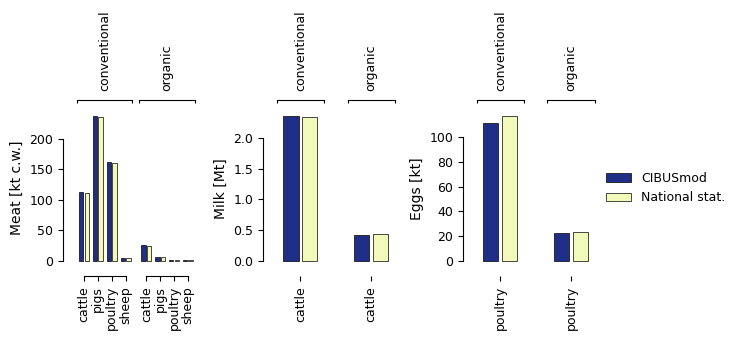

In [5]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','sheep','meat')     : tot_sheep_meat-org_sheep_meat,
        ('organic','sheep','meat')          : org_sheep_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    session.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).loc[(scn,year)].rename('CIBUSmod')/1000000,
    stat.rename('National stat.')
], axis=1)

aps = plot_data.drop('horses', level='species').index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(1,3, figsize=(7.5,3.5))

i=0
for ap in aps:
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.xs(ap,level='animal_prod') * (1/1000 if ap == 'milk' else 1),
        ax = ax,
        ylabel=f'{ap.capitalize()} [{"Mt" if ap == "milk" else "kt"}{" c.w." if ap == "meat" else ""}]',
        stacked = False,
        group_levels='prod_system',
        grouplabels_vertical=True,
        **bar_style
    )
    i+=1

for i, ax in enumerate(axs.flatten()):
    if i == 2:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
    else:
        ax.legend().set_visible(False)
    
plt.tight_layout()
plt.show()

##### Detailed slaughter for cattle

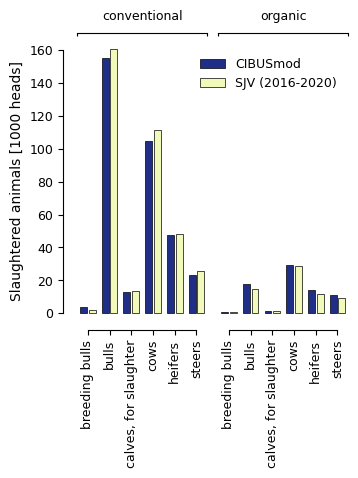

In [6]:
SJV_slaughter_n = pd.Series({'Ungko':36,
                           'Ko':104,
                           'Kviga':60,
                           'Mellankalv':15,
                           'Stut':35,
                           'Ungtjur':154,
                           'Yngre tjur':21,
                           'Äldre tjur':3})

SJV_org_prc = pd.Series({'Ungko':18.46,
                           'Ko':20.98,
                           'Kviga':19.28,
                           'Mellankalv':7.72,
                           'Stut':27.14,
                           'Ungtjur':7.72,
                           'Yngre tjur':12.48,
                           'Äldre tjur':27.5})

rename_dict = {'Ungko':'cows', 'Ko':'cows', 'Kviga':'heifers',
               'Mellankalv':'calves, for slaughter', 'Stut':'steers',
               'Ungtjur':'bulls', 'Yngre tjur':'bulls', 'Äldre tjur':'breeding bulls'}

SJV_df = pd.concat([(SJV_slaughter_n * (1-SJV_org_prc/100)).rename('conventional'),
                    (SJV_slaughter_n * (SJV_org_prc/100)).rename('organic')], axis=1)
SJV_df = (
    SJV_df.rename(rename_dict)
    .rename_axis(index='animal', columns='prod_system')
    .groupby('animal').sum()
    .unstack()
    .rename('SJV (2016-2020)')
)

cm_df = session.get_attr('a','slaughtered_n',['species','prod_system','animal']).loc[(scn,year),'cattle'].rename('CIBUSmod') / 1_000

plot_data = pd.concat([cm_df, SJV_df], axis=1)

fig, ax = plt.subplots(figsize=(3.5,3.5))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='prod_system',
    ylabel='Slaughtered animals [1000 heads]',
    ax=ax,
    **bar_style
)
plt.show()

#### Animal numbers

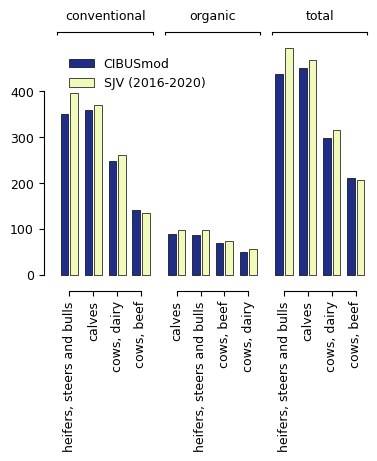

In [7]:
plot_data = session.get_attr('a','heads',{'species':None,'prod_system':None,'breed':None,'animal':None}, 'base year').loc[(scn,year),'cattle'] / 1_000
plot_data.index = pd.MultiIndex.from_tuples(
    [(ps, ', '.join([an, br]) if an == 'cows' else 'calves' if 'calves' in an else 'heifers, steers and bulls') for ps,br,an in plot_data.index],
    names = ['prod_system', 'animal']
)
plot_data = plot_data.groupby(['prod_system','animal']).sum().unstack('prod_system')
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.stack().rename('CIBUSmod')

sjv = pd.Series({
    # Average 2016-2020
    ('cows, dairy', 'conventional') : 316_238 * (1 - 0.174),
    ('cows, dairy', 'organic') : 316_238 * 0.174,
    ('cows, dairy', 'total') : 316_238,

    ('cows, beef', 'conventional') : 206_514 * (1 - 0.352),
    ('cows, beef', 'organic') : 206_514 * 0.352,
    ('cows, beef', 'total') : 206_514,

    ('calves', 'conventional') : 467_134.4 * (1 - 0.208),
    ('calves', 'organic') : 467_134.4 * 0.208,
    ('calves', 'total') : 467_134.4,

    ('heifers, steers and bulls', 'conventional') : 493_490.2 * (1 - 0.196),
    ('heifers, steers and bulls', 'organic') : 493_490.2 * 0.196,
    ('heifers, steers and bulls', 'total') : 493_490.2,
}).rename('SJV (2016-2020)') / 1_000
sjv.index.names = ['animal','prod_system']

fig,ax = plt.subplots(figsize=(4,3))
cm.plot.bar(
    pd.concat([plot_data, sjv], axis=1),
    group_levels=['prod_system'],
    stacked=False,
    ax=ax,
    **bar_style,
    sort_xlabels=True
)
plt.show()

### Crop production and use compared to statistics

#### Cereals

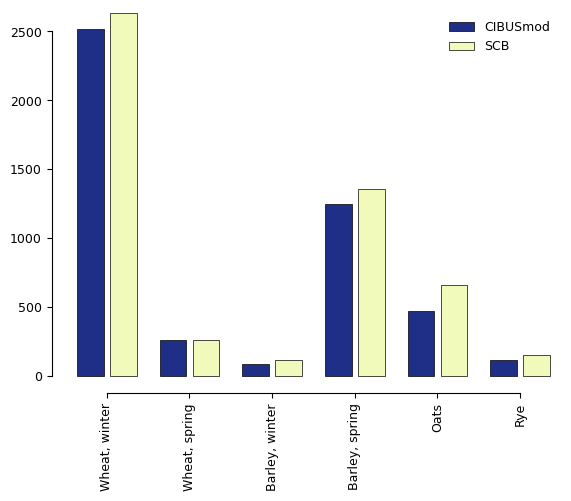

In [8]:
data = (
    session.get_attr('c','production')
    .loc[(scn,year)]
    .groupby('crop').sum()
    .loc[['Wheat, winter', 'Wheat, spring','Barley, winter', 'Barley, spring','Oats','Rye']]
    .rename('CIBUSmod')
)/1000000

plot_data = pd.concat([
    data,
    pd.Series([2631,259,112,1353,658,149], index=data.index, name='SCB') # SCB stat database. Total harvest. Average 2016-2020
], axis=1)


cm.plot.bar(
    plot_data,
    stacked = False,
    # ax = ax,
    **bar_style
)
plt.show()

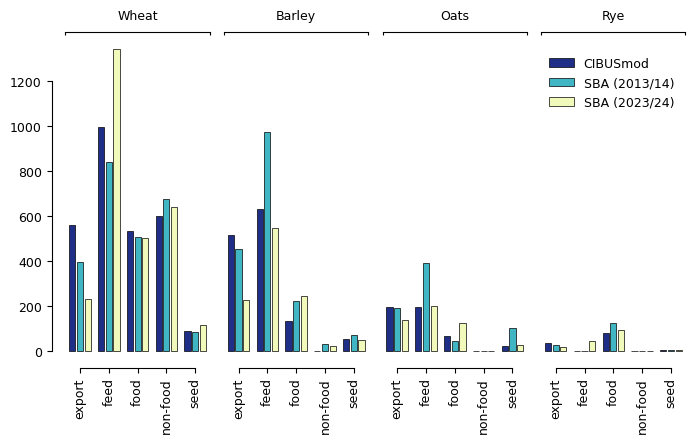

,CIBUSmod,SBA (2013/14),SBA (2023/24)
crop,,,
Barley,1328.0,1743,1084
Oats,473.0,720,486
Rye,114.0,151,158
Wheat,2773.0,2496,2828


In [9]:
cm_data = (
    session.get_attr('c','production_per_use')
    .loc[(scn,year)]
    .rename(lambda x: x.replace(', spring','').replace(', winter',''), level='crop')
    .rename(lambda x: 'feed' if 'feed' in x else x, level='demand')
    .groupby(['crop','demand']).sum()
    .loc[['Wheat','Barley','Oats','Rye']]
    .rename('CIBUSmod')
)/1_000_000

SBA_1314 = pd.Series({
    # https://www2.jordbruksverket.se/webdav/files/SJV/trycksaker/Pdf_rapporter/ra14_8.pdf
    ('Wheat', 'export') : 396,
    ('Wheat', 'feed') : 837,
    ('Wheat', 'food') : 505,
    ('Wheat', 'non-food') : 673,
    ('Wheat', 'seed') : 85,
                     
    ('Barley', 'export') : 454,
    ('Barley', 'feed') : 970,
    ('Barley', 'food') : 221,
    ('Barley', 'non-food') : 30,
    ('Barley', 'seed') : 68,
                     
    ('Oats', 'export') : 190,
    ('Oats', 'feed') : 389,
    ('Oats', 'food') : 41,
    ('Oats', 'non-food') : 0,
    ('Oats', 'seed') : 100,

    ('Rye', 'export') : 24,
    ('Rye', 'feed') : 0,
    ('Rye', 'food') : 124,
    ('Rye', 'non-food') : 0,
    ('Rye', 'seed') : 3,
}, name='SBA (2013/14)').rename_axis(['crop','demand'])

SBA_2324 = pd.Series({
    ('Wheat', 'export') : 230,
    ('Wheat', 'feed') : 1_342,
    ('Wheat', 'food') : 503,
    ('Wheat', 'non-food') : 638,
    ('Wheat', 'seed') : 115,
                     
    ('Barley', 'export') : 225,
    ('Barley', 'feed') : 546,
    ('Barley', 'food') : 245,
    ('Barley', 'non-food') : 22,
    ('Barley', 'seed') : 46,
                     
    ('Oats', 'export') : 135,
    ('Oats', 'feed') : 200,
    ('Oats', 'food') : 125,
    ('Oats', 'non-food') : 0,
    ('Oats', 'seed') : 26,

    ('Rye', 'export') : 15,
    ('Rye', 'feed') : 45,
    ('Rye', 'food') : 94,
    ('Rye', 'non-food') : 0,
    ('Rye', 'seed') : 4,
}, name='SBA (2023/24)').rename_axis(['crop','demand'])

plot_data = pd.concat([cm_data, SBA_1314, SBA_2324], axis=1)

fig, ax = plt.subplots(figsize=(8,4))
cm.plot.bar(
    plot_data,
    group_levels='crop',
    stacked=False,
    **bar_style
)
plt.show()

plot_data.groupby('crop').sum().round()

### Manure excretion

#### Volatile solids

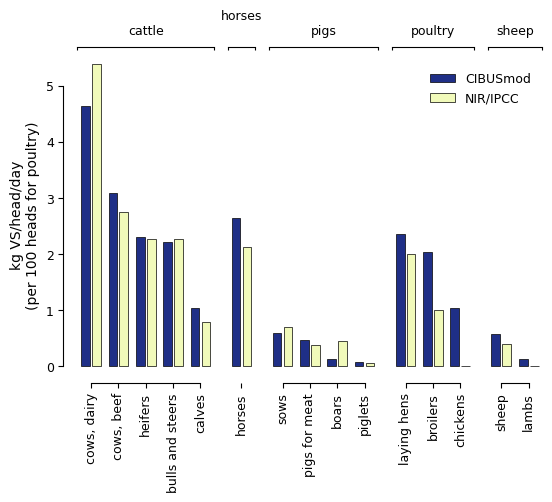

In [10]:
VS = session.get_attr('A','manure.VS_excr',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
heads = session.get_attr('A','heads',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
new_idx = pd.MultiIndex.from_tuples(
    [(sp, f'{an}, {br}')  if an == 'cows' else (sp, an) for sp,br,an in VS.index],
    names = ['species','animal']
)
VS.index = new_idx
heads.index = new_idx
VS = VS.T.groupby(['species','animal']).sum().T
heads = heads.T.groupby(['species','animal']).sum().T
VS_per_head = (VS/heads/365.25).rename('CIBUSmod')


NIR_IPCC = pd.Series({
    # Swedish NIR 2023, Table 5.16
    ('cattle', 'cows, dairy') : 5.39,
    ('cattle', 'cows, beef') : 2.74, # Avg. grazing / stable
    ('cattle', 'calves') : 0.79,
    ('cattle', 'heifers') : 2.26,
    ('cattle', 'bulls and steers') : 2.26,
    ('horses', 'horses') : 2.13,
    ('pigs', 'sows') : 0.69,
    ('pigs', 'boars') : 0.45,
    ('pigs', 'piglets') : 0.044,
    ('pigs', 'pigs for meat') : 0.37,
    # IPCC 2006, Table 10A-9
    ('sheep', 'sheep') : 0.4,
    ('sheep', 'lambs') : np.nan,
    ('poultry','laying hens') : 0.02,
    ('poultry','broilers') : 0.01,
    ('poultry','chickens') : np.nan
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

plot_data = plot_data.mul((plot_data.index.get_level_values('species') == 'poultry') * 99 + 1, axis=0)

fig, ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='species',
    sort_xlabels=True,
    ylabel='kg VS/head/day\n(per 100 heads for poultry)',
    ax=ax,
    **bar_style
)
plt.show()

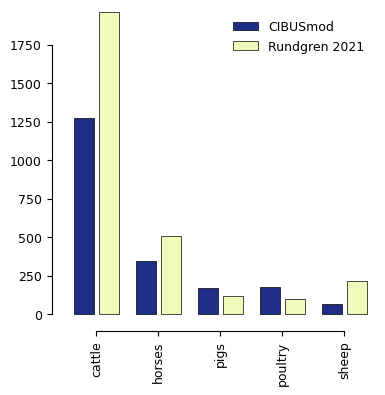

In [11]:
# Compared to Rundgren 2021
plot_data = pd.concat([
    session.get_attr('A','manure.VS_excr','species').loc[(scn,year)].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked = False,
    ax = ax,
    **bar_style
)
plt.show()

#### Nitrogen

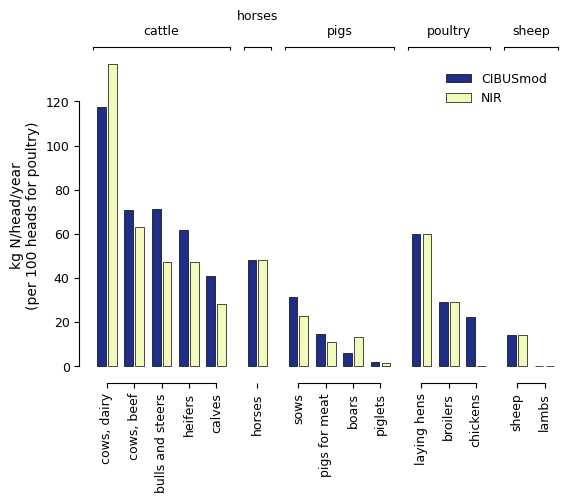

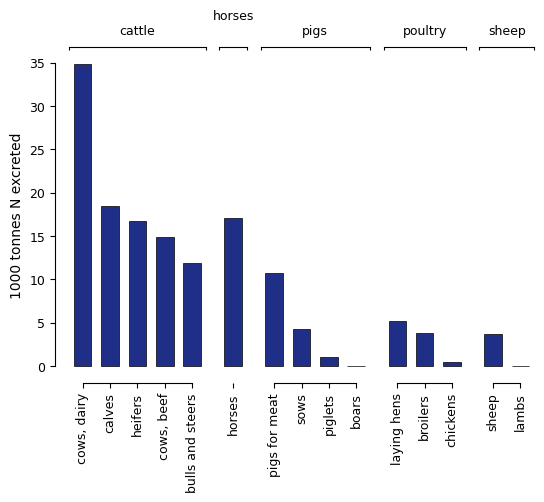

In [12]:
N = session.get_attr('A','manure.N_excr',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
heads = session.get_attr('A','heads',{'species':None,'breed':None,'animal':'animal_NIR'}).loc[(scn,year)]
N = N.reindex(heads.index)
new_idx = pd.MultiIndex.from_tuples(
    [(sp, f'{an}, {br}')  if an == 'cows' else (sp, an) for sp,br,an in N.index],
    names = ['species','animal']
)
N.index = new_idx
heads.index = new_idx
N = N.T.groupby(['species','animal']).sum().T
heads = heads.T.groupby(['species','animal']).sum().T
N_per_head = (N/heads).rename('CIBUSmod')

# Swedish NIR 2023, Table 5.15 and 5.17
NIR = pd.Series({
    ('cattle','cows, dairy'):137,
    ('cattle','cows, beef'):63,
    ('cattle','calves'):28,
    ('cattle','heifers'):47,
    ('cattle','bulls and steers'):47,
    ('horses','horses') : 48,
    ('pigs','sows') : 22.5,
    ('pigs','boars') : 13,
    ('pigs','piglets') : 1.2,
    ('pigs','pigs for meat') : 10.8,
    ('poultry','laying hens') : 0.6,
    ('poultry','broilers') : 0.29,
    ('poultry','chickens') : np.nan,
    ('sheep', 'sheep') : 14, # includes lambs
    ('sheep','lambs') : 0
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

plot_data = plot_data.mul((plot_data.index.get_level_values('species') == 'poultry') * 99 + 1, axis=0)

fig, ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='species',
    sort_xlabels=True,
    ylabel='kg N/head/year\n(per 100 heads for poultry)',
    ax=ax,
    **bar_style
)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    N/1_000_000,
    stacked=False,
    group_levels='species',
    sort_xlabels=True,
    ylabel='1000 tonnes N excreted',
    ax=ax,
    **bar_style
)
plt.show()

### GHG emissions compared to NIR

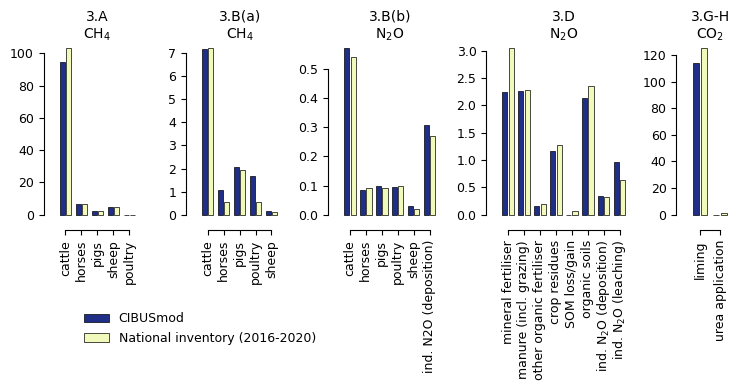

CIBUSmod     NIR        dif
table  compound                                                        
3.A    CH$_4$   cattle                     94.987029  103.12  -8.132971
                horses                      6.399000    6.40  -0.001000
                pigs                        2.121485    2.13  -0.008515
                sheep                       4.553439    4.51   0.043439
                poultry                          NaN     NaN        NaN
3.B(a) CH$_4$   cattle                      7.169958    7.20  -0.030042
                horses                      1.086310    0.55   0.536310
                pigs                        2.081533    1.93   0.151533
                poultry                     1.687749    0.53   1.157749
                sheep                       0.162906    0.11   0.052906
3.B(b) N$_2$O   cattle                      0.570908    0.54   0.030908
                horses                      0.085647    0.09  -0.004353
                pigs                        0.098432    0.09   0.008432
                poultry                     0.093704    0.10  -0.006296
                sheep                       0.028264    0.02   0.008264
                ind. N2O (deposition)       0.306243    0.27   0.036243
3.D    N$_2$O   mineral fertiliser          2.249563    3.04  -0.790437
                manure (incl. grazing)      2.268015    2.28  -0.011985
                other organic fertiliser    0.164229    0.20  -0.035771
                crop residues               1.157971    1.28  -0.122029
                SOM loss/gain                    NaN    0.07        NaN
                organic soils               2.130345    2.36  -0.229655
                ind. N$_2$O (deposition)    0.338451    0.32   0.018451
                ind. N$_2$O (leaching)      0.968001    0.64   0.328001
3.G-H  CO$_2$   liming                    114.319508  125.00 -10.680492
                urea application                 NaN    0.93        NaN

,CIBUSmod,NIR,dif,%dif
compound,,,,
CH$_4$,120.249410,126.48,-6.230590,-4.926146
CO$_2$,114.319508,125.93,-10.680492,-8.481293
N$_2$O,10.459773,11.30,-0.770227,-6.816164


In [90]:
# Data from Sweden's national GHG inventory sourced from CRF tables
# https://unfccc.int/ghg-inventories-annex-i-parties/2023
# Values are averaged for the years 2016-2020

# Enteric fermentation (Table 3.A) ----------------------------->

cbm = (
    session.get_attr('a','enteric_methane','species')
    .loc[(scn,year)]
    .rename('CIBUSmod')
    /1_000_000
)

nir = pd.Series({
    'cattle':103.12,
    'sheep':4.51,
    'pigs':2.13,
    'poultry':np.nan,
    'horses':6.4
}).rename_axis('species').rename('NIR')

d1 = pd.concat([cbm, nir], axis=1)
d1['dif'] = (d1['CIBUSmod'] - d1['NIR'])
d1 = pd.concat({'CH$_4$': d1}, names=['compound'])
d1 = pd.concat({'3.A': d1}, names=['table'])

# Manure mgmt (Table 3.B(a)) ----------------------------->

cbm = (
    session.get_attr('a','manure.VS_loss',['compound','species'])
    .loc[(scn,year),'CH4bio']
    .rename('CIBUSmod')
    /1_000_000
)

nir = pd.Series({
    'cattle':7.20,
    'sheep':0.11,
    'pigs':1.93,
    'poultry':0.53,
    'horses':0.55
}).rename_axis('species').rename('NIR')

d2 = pd.concat([cbm, nir], axis=1)
d2['dif'] = (d2['CIBUSmod'] - d2['NIR'])
d2 = pd.concat({'CH$_4$': d2}, names=['compound'])
d2 = pd.concat({'3.B(a)': d2}, names=['table'])

# Manure mgmt (Table 3.B(b)) ----------------------------->

cbm_ = (
    session.get_attr('a','manure.N_loss',['compound','species'])
    .loc[(scn,year)]
    .rename('CIBUSmod')
    /1_000_000
)

cbm = cbm_.loc['N2O-N'] * (44/28)
cbm['ind. N2O (deposition)'] = cbm_.loc[['NH3-N','NOx-N']].sum() * 0.010 * (44/28)

nir = pd.Series({
    'cattle':0.54,
    'sheep':0.02,
    'pigs':0.09,
    'poultry':0.10,
    'horses':0.09,
    'ind. N2O (deposition)':0.27
}).rename_axis('species').rename('NIR')

d3 = pd.concat([cbm, nir], axis=1)
d3 = pd.concat({'N$_2$O': d3}, names=['compound'])
d3 = pd.concat({'3.B(b)': d3}, names=['table'])
d3['dif'] = (d3['CIBUSmod'] - d3['NIR'])

# Agricultural soils (Table 3.D) ----------------------------->

cbm = pd.Series({
    'mineral fertiliser' : session.get_attr('c','fertiliser.mineral_N_soil_loss','none').loc[(scn,year)],
    'manure (incl. grazing)' : session.get_attr('c','fertiliser.manure_N_soil_loss','none').loc[(scn,year)],
    'other organic fertiliser' : session.get_attr('c','fertiliser.organic_N_soil_loss','none').loc[(scn,year)],
    'crop residues' : session.get_attr('c','fertiliser.crop_residues_N_soil_loss','none').loc[(scn,year)],
    'SOM loss/gain' : np.nan,
    'organic soils' : session.get_attr('c','organic_soil_losses','compound').loc[(scn,year), 'N2O-N'],
    'ind. N$_2$O (deposition)' : (
        session.get_attr('c','fertiliser.mineral_N_application_loss','none').loc[(scn,year)] +
        session.get_attr('c','fertiliser.manure_N_application_loss','none').loc[(scn,year)] +
        session.get_attr('c','fertiliser.organic_N_application_loss','none').loc[(scn,year)]
    ) * 0.010,
    'ind. N$_2$O (leaching)' : session.get_attr('c','fertiliser.leaching_N','none').loc[(scn,year)] * 0.0075
}).rename('CIBUSmod')*(44/28)/1_000_000

nir = pd.Series({
    'mineral fertiliser' : 3.04,
    'manure (incl. grazing)' : 1.10+1.18,
    'other organic fertiliser' : 0.20,
    'crop residues' : 1.28,
    'SOM loss/gain' : 0.07,
    'organic soils' : 2.36,
    'ind. N$_2$O (deposition)' : 0.32,
    'ind. N$_2$O (leaching)' : 0.64
}).rename('NIR')

d4 = pd.concat([cbm, nir], axis=1)
d4 = pd.concat({'N$_2$O': d4}, names=['compound'])
d4 = pd.concat({'3.D': d4}, names=['table'])
d4['dif'] = (d4['CIBUSmod'] - d4['NIR'])

# Liming and Urea (Table 3.G-H) ----------------------------->

cbm = pd.Series({
    'liming' : session.get_attr('c', 'fertiliser.liming_emissions', 'none').loc[(scn,year)]/1_000_000,
    'urea application' : np.nan
}).rename('CIBUSmod')

nir = pd.Series({
    'liming' : 125.00,
    'urea application' : 0.93
}).rename('NIR')

d5 = pd.concat([cbm, nir], axis=1)
d5['dif'] = (d5['CIBUSmod'] - d5['NIR'])
d5 = pd.concat({'CO$_2$': d5}, names=['compound'])
d5 = pd.concat({'3.G-H': d5}, names=['table'])

# Combine and plot ----------------------------->

plot_data = pd.concat([d1,d2,d3,d4,d5])

tab_cmps = plot_data.droplevel(2).index.unique()
lens = [len(plot_data.loc[(tab,cmp)]) for tab,cmp in tab_cmps]

fig, axs = plt.subplots(1,len(lens), figsize=(7.5,4), gridspec_kw={'width_ratios': [max(l,2.5) for l in lens]})

i=0
for tab, cmp in tab_cmps:
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[(tab,cmp),('CIBUSmod','NIR')].rename(columns={'NIR':'National inventory (2016-2020)'}),
        ax = ax,
        stacked=False,
        **bar_style
    )
    ax.set_title(f'{tab}\n{cmp}', fontsize=10)
    ax.legend().set_visible(False)
    i+=1

plt.tight_layout()
axs[1].legend(loc='upper center', fontsize=9, bbox_to_anchor=(0, -0.5), ncol=1, frameon=False)
plt.savefig('figs/Fig9.png', dpi=300)
plt.show()

display(plot_data)

tab_data = plot_data.groupby('compound').sum()
tab_data['%dif'] = tab_data['dif'] / tab_data['NIR'] * 100
display(tab_data)

#### Check VS excretion and CH4 from manure management for poultry

In [16]:
print('---------------')
print('kg CH4/head/year (all poultry):')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','compound']).loc[(scn,year),('poultry','CH4bio')] /
session.get_attr('a','heads',['species']).loc[(scn,year),('poultry')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound']).loc[(scn,year),('poultry',slice(None),'CH4bio')] /
session.get_attr('a','heads',['species','breed']).loc[(scn,year),('poultry')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound','animal']).loc[(scn,year),('poultry','broiler','CH4bio')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')])

print('')
print('---------------')
print('kg CH4/head/year:')
print('---------------')
print(session.get_attr('a','manure.VS_loss',['species','breed','compound','animal']).loc[(scn,year),('poultry','layer','CH4bio')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')])

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed']).loc[(scn,year),('poultry')] /
session.get_attr('a','heads',['species','breed']).loc[(scn,year),('poultry')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day:')
print('---------------')
print(session.get_attr('a','manure.VS_excr',['species','breed','animal']).loc[(scn,year),('poultry','layer')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')] / 365.25)

print('')
print('---------------')
print('kg VS/head/day (calc. from 72% DM digestibility):')
print('---------------')
print(session.get_attr('a','feed.consumption',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','broiler')] / 365.25 * (1-0.72) * (1-0.05))

print('')
print('---------------')
print('kg VS/head/day (calc. from 72% DM digestibility):')
print('---------------')
print(session.get_attr('a','feed.consumption',['species','breed','animal']).loc[(scn,year),('poultry','layer')] /
session.get_attr('a','heads',['species','breed','animal']).loc[(scn,year),('poultry','layer')] / 365.25 * (1-0.73) * (1-0.05))

---------------
kg CH4/head/year (all poultry):
---------------
0.07180361123815739

---------------
kg CH4/head/year:
---------------
species  breed    compound
poultry  broiler  CH4bio      0.036398
         layer    CH4bio      0.124046
Name: (base year, 2020), dtype: float64

---------------
kg CH4/head/year:
---------------
animal
breeding hens        0.162365
breeding roosters         NaN
broilers             0.026966
Name: (base year, 2020), dtype: float64

---------------
kg CH4/head/year:
---------------
animal
breeding hens and roosters    0.145941
laying chicks                 0.062960
laying hens (16-28 weeks)     0.150101
laying hens (29-59 weeks)     0.132313
laying hens (>59 weeks)       0.147440
Name: (base year, 2020), dtype: float64

---------------
kg VS/head/day:
---------------
breed
broiler    0.020888
layer      0.020342
Name: (base year, 2020), dtype: float64

---------------
kg VS/head/day:
---------------
animal
breeding hens        0.028844
breeding roosters 

#### Check area organic soils

In [17]:
area = session.get_attr('c','area',{'crop':'land_use'}).loc[(scn,year)].drop('greenhouse')/1_000
org_soils = session.get_attr('c','organic_soil_area',{'crop':'land_use'}).loc[(scn,year)]/1_000

org_soils = pd.concat([org_soils.rename('1000 ha'),(org_soils/area*100).rename('%')], axis=1)
print('')
print('---------------')
print('Area organic soils:')
print('---------------')
display(org_soils.style.format('{:.1f}'))


---------------
Area organic soils:
---------------


,1000 ha,%
land_use,,
cropland,95.2,4.0
semi-natural grasslands,42.1,7.7


#### Check crop residues

In [19]:
d1 = session.get_attr('c','crop_residues','residue').loc[(scn,year)]/1_000_000
d2 = session.get_attr('c','crop_residues_harvest','none').loc[(scn,year)]/1_000_000
d3 = d1.copy()
d3.loc['above ground'] -= d2
d4 = session.get_attr('c','fertiliser.crop_residues_N','residue').loc[(scn,year)]/1_000_000
d4.loc['total'] = d4.sum()
d4b = session.get_attr('c','fertiliser.crop_residues_N','residue').loc[('base year (x0 crop areas)',year)]/1_000_000
d4b.loc['total'] = d4b.sum()
d5 = session.get_attr('c','fertiliser.crop_residues_N',{'crop':'crop_group', 'residue':None}).loc[(scn,year)]/1_000_000
d6 = (
    session.get_attr('c','crop_residues_harvest',{'crop':'crop_group'}).div(
        session.get_attr('c','crop_residues',{'residue':None,'crop':'crop_group'}).loc[:,'above ground'], fill_value=0
    )
).loc[(scn,year)]

NIR_CR_N = pd.DataFrame({
    'above ground' : {'2015':46_280,'2018':30_731,'2019':48_559,'2020':46_957},
    'below ground' : {'2015':41_321,'2018':26_987,'2019':42_675,'2020':40_935}
}).T / 1_000
NIR_CR_N.loc['total'] = NIR_CR_N.sum()
NIR_CR_N.loc[:,'2015-2020'] = NIR_CR_N.mean(axis=1)

print('')
print('---------------')
print('Generated crop residues [1000 tonnes DM]:')
print('---------------')
print(d1)

print('')
print('---------------')
print('Harvested crop residues [1000 tonnes DM]:')
print('---------------')
print(d2)

print('')
print('---------------')
print('Crop residues left in field [1000 tonnes DM]:')
print('---------------')
print(d3)

print('')
print('---------------')
print('N in crop residues left in field [1000 tonnes N]:')
print('---------------')
print(pd.concat([d4.rename('CIBUSmod'),d4b.rename('CIBUSmod (x0)'),NIR_CR_N], axis=1).round(1))

print('')
print('---------------')
print('N in crop residues left in field [1000 tonnes N]:')
print('---------------')
print(d5)

print('')
print('---------------')
print('Fraction crop residues removed:')
print('---------------')
print(d6)


---------------
Generated crop residues [1000 tonnes DM]:
---------------
residue
above ground    4998.427624
below ground    3231.872754
Name: (base year, 2020), dtype: float64

---------------
Harvested crop residues [1000 tonnes DM]:
---------------
1532.0542842550371

---------------
Crop residues left in field [1000 tonnes DM]:
---------------
residue
above ground    3466.373340
below ground    3231.872754
Name: (base year, 2020), dtype: float64

---------------
N in crop residues left in field [1000 tonnes N]:
---------------
              CIBUSmod  CIBUSmod (x0)  2015  2018  2019  2020  2015-2020
above ground      36.7           41.4  46.3  30.7  48.6  47.0       43.1
below ground      38.1           41.9  41.3  27.0  42.7  40.9       38.0
total             74.8           83.3  87.6  57.7  91.2  87.9       81.1

---------------
N in crop residues left in field [1000 tonnes N]:
---------------
crop_group              residue     
Berries                 above ground     0.058160

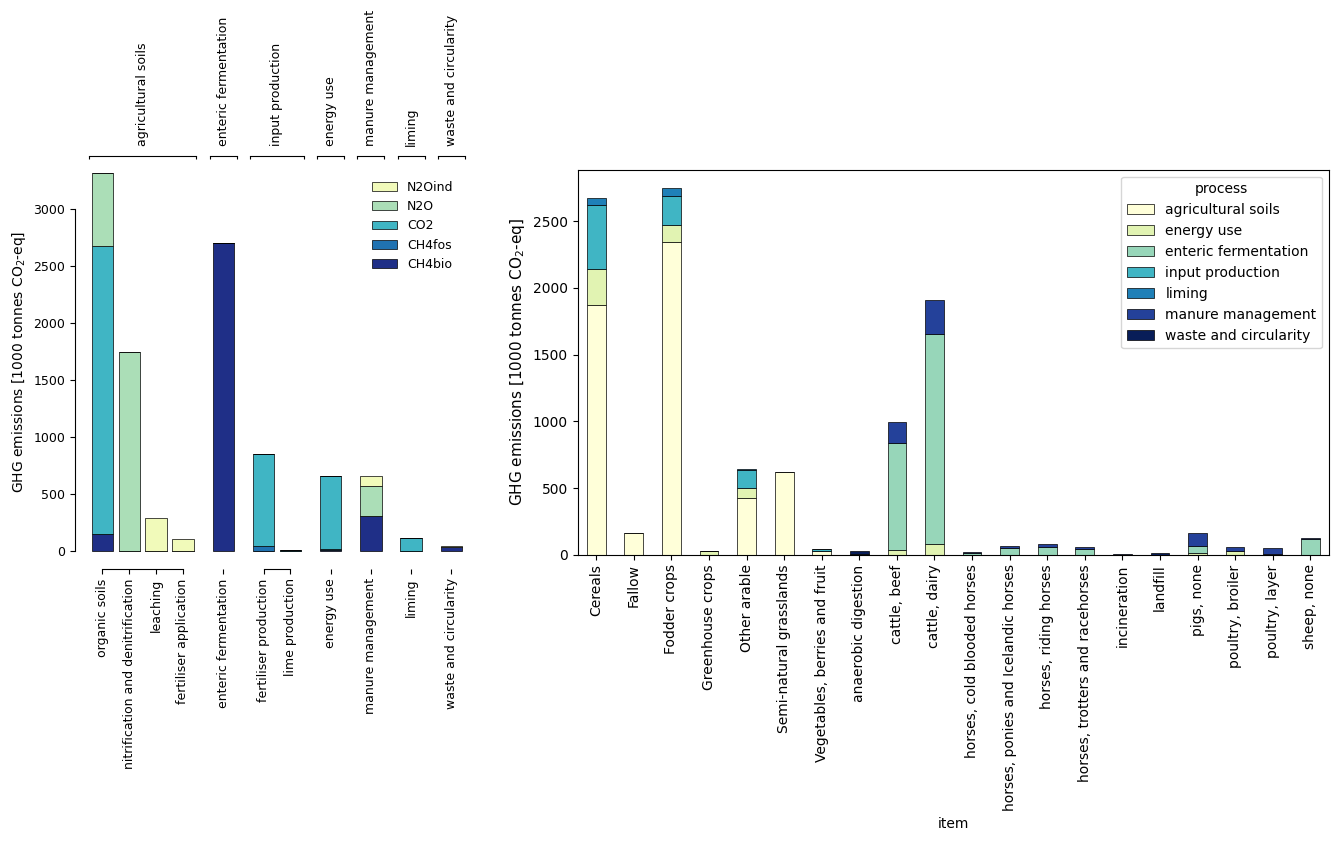

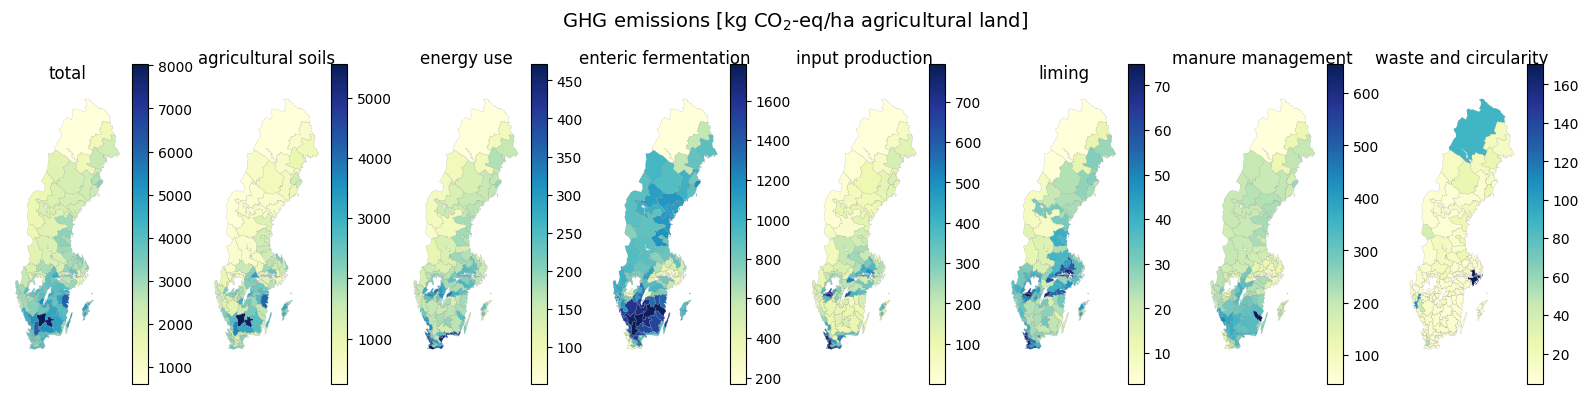

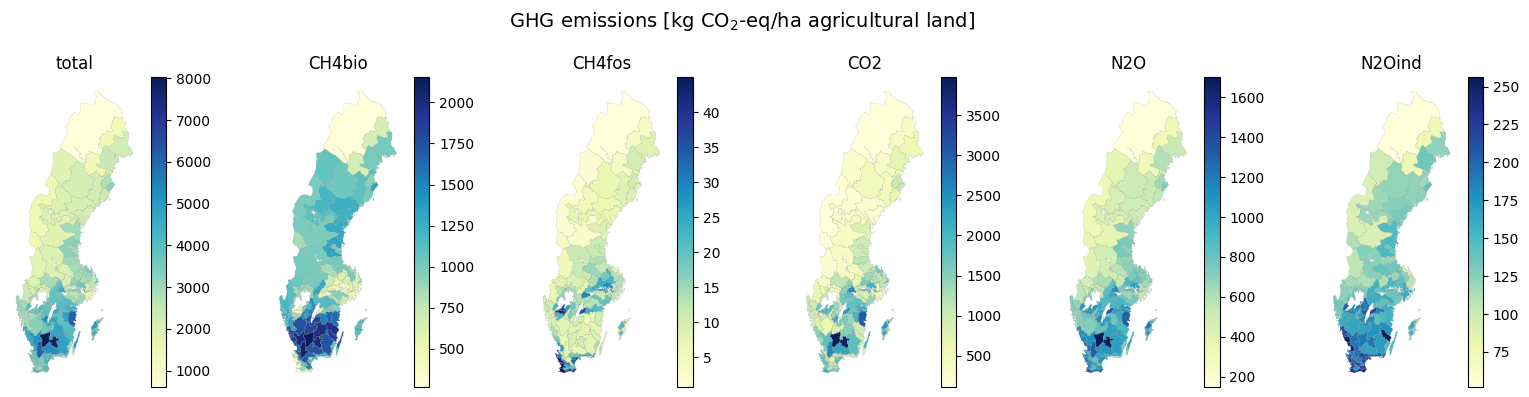

In [20]:
# Bar plot [1000 tonnes CO2eq] ----->

GHG_data = cm.impact.get_GHG(session, scn='base year')

fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['process','sub-process','compound'])
    .sum()
    .unstack()
    /1000000
)

ax=axs[0]
cm.plot.bar(
    plot_data,
    ax = ax,
    sort_groups=True,
    sort_xlabels=True,
    group_levels='process',
    grouplabels_vertical=True,
    ylabel='GHG emissions [1000 tonnes CO$_2$-eq]',
    **bar_style
)

# plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
# ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
ax.set_ylabel(r'GHG emissions [1000 tonnes CO$_2$-eq]', size=11)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year)].drop('greenhouse')
    .groupby('region').sum()
)

# per process
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','process'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_proc = len(plot_data.columns)

fig, axs = plt.subplots(1,n_proc+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

# per GHG
plot_data = (
    GHG_data.loc[(scn,year)]
    .groupby(['region','compound'])
    .sum()
    .unstack()
    .mul(1/area, axis=0)
)
n_ghg = len(plot_data.columns)

fig, axs = plt.subplots(1,n_ghg+1, figsize=(16,4))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for cp in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[cp], **map_style, ax=ax)
    ax.set_title(cp)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.tight_layout()
plt.show()

### N, P, K application and balances

#### Compared to SCB statistics

In [95]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga areas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total for sweden (SCB, Gödselemedl i jordbruket)
# Avg. 2015/2016, 2018/2019 and 2021/2022
stat_total = pd.Series({ # [1000 tonnes N/P/K]
    ('N','mineral fertiliser') : 170,
    ('N','manure')  : 78,
    ('N','organic fertiliser') : (3590+4370)/2/1000/0.4, # Tablå 3, avg 2018/19 and 2021/22, assuming 40% of N plant available
    ('P','mineral fertiliser') : 13,
    ('P','manure')  : 17,
    ('P','organic fertiliser') : (820+910)/2/1000, # Tablå 3, avg 2018/19 and 2021/22
    ('K','mineral fertiliser') : 29,
    ('K','manure')  : 92,
    ('K','organic fertiliser') : (2960+3110)/2/1000 # Tablå 3, avg 2018/19 and 2021/22
})
stat_crop_tot = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 2.7,
    ('N', 'Other') : 37,
    ('N', 'Ley for fodder') : 79,
    ('N', 'Cereals') : 130,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.3,
    ('P', 'Other') : 6.1,
    ('P', 'Ley for fodder') : 10,
    ('P', 'Cereals') : 14,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 1.7,
    ('K', 'Other') : 22,
    ('K', 'Ley for fodder') : 60,
    ('K', 'Cereals') : 37,
})
stat_crop_tot_mineral = pd.Series({ # [1000 tonnes N/P/K]
    ('N', 'Not included') : np.nan,
    ('N', 'Ley for grazing') : 1.6,
    ('N', 'Other') : 25,
    ('N', 'Ley for fodder') : 38,
    ('N', 'Cereals') : 106,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 0.1,
    ('P', 'Other') : 3.4,
    ('P', 'Ley for fodder') : 1.4,
    ('P', 'Cereals') : 8.2,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 0.3,
    ('K', 'Other') : 10,
    ('K', 'Ley for fodder') : 5,
    ('K', 'Cereals') : 13,
})
stat_crop_per_ha = pd.Series({ # [kg N/P/K per ha]
    ('N', 'Not included') : np.nan, # Not incl
    ('N', 'Ley for grazing') : 24,
    ('N', 'Other') : 116,
    ('N', 'Ley for fodder') : 111,
    ('N', 'Cereals') : 133,
    ('P', 'Not included') : np.nan,
    ('P', 'Ley for grazing') : 2.9,
    ('P', 'Other') : 20,
    ('P', 'Ley for fodder') : 15,
    ('P', 'Cereals') : 16,
    ('K', 'Not included') : np.nan,
    ('K', 'Ley for grazing') : 16,
    ('K', 'Other') : 71,
    ('K', 'Ley for fodder') : 88,
    ('K', 'Cereals') : 44,
})

---------
base year
---------
N


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,145,170,-15
manure,77,78,-1
organic fertiliser,11,10,6


P


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,9,13,-28
manure,17,17,-1
organic fertiliser,1,1,65


K


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,18,29,-38
manure,94,92,2
organic fertiliser,5,3,51


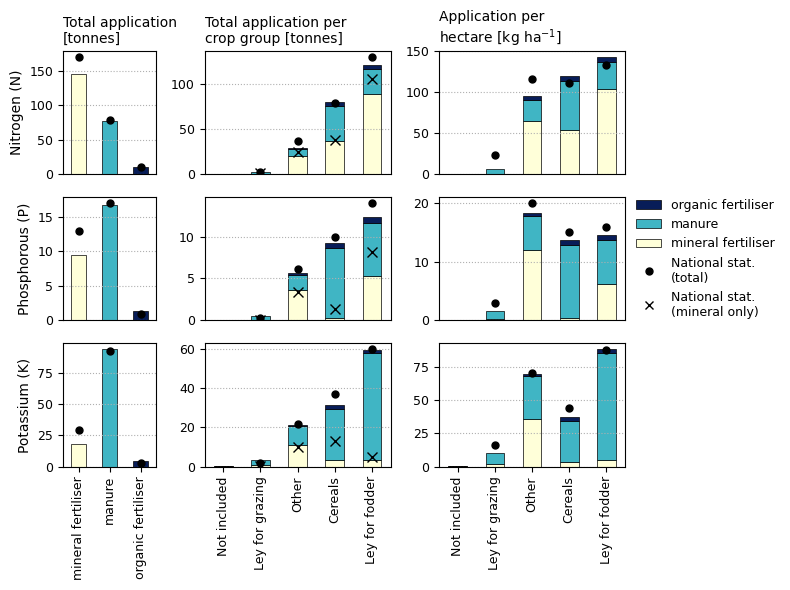

-------------------------
base year (x0 crop areas)
-------------------------
N


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,172,170,1
manure,77,78,-1
organic fertiliser,11,10,6


P


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,12,13,-9
manure,17,17,-1
organic fertiliser,1,1,65


K


,CIBUSmod,SCB (2016-2020),Difference
mineral fertiliser,23,29,-21
manure,94,92,2
organic fertiliser,5,3,51


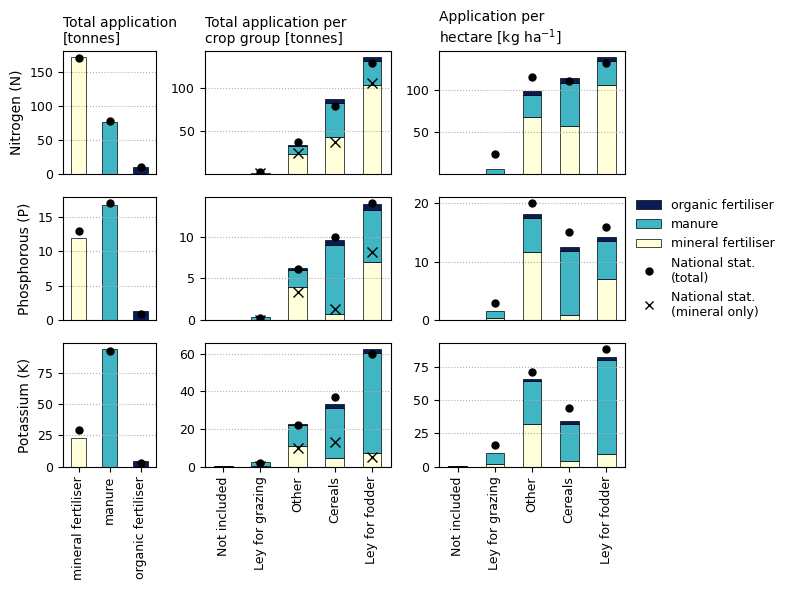

In [71]:
elem_to_name = {
    'N' : 'Nitrogen (N)',
    'P' : 'Phosphorous (P)',
    'K' : 'Potassium (K)'
}

for scn in ['base year', 'base year (x0 crop areas)']:
    print('-'*len(scn), scn, '-'*len(scn), sep='\n')
    fig, axs_ = plt.subplots(3,3, figsize=(8,6), gridspec_kw={'width_ratios': [1, 2, 2]})
    for i, element in enumerate(['N','P','K']):
        axs = axs_[i]
        area = (
            session.get_attr(
                'C',
                'area',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
        )
        mineral_fert = (
            session.get_attr(
                'C',f'fertiliser.mineral_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('mineral fertiliser')
        )
        manure = (
            session.get_attr(
                'C',
                f'fertiliser.manure_{element}',
                {'crop':'crop_group_fertstat', 'MMS':None}
            )
            .loc[(scn,year)]
            .drop('grazing', level='MMS')
            .groupby('crop_group_fertstat')
            .sum()
            .rename('manure')
        )
        organic_fert = (
            session.get_attr(
                'C',f'fertiliser.organic_{element}',
                {'crop':'crop_group_fertstat'}
            )
            .loc[(scn,year)]
            .rename('organic fertiliser')
        )
        
        plot_data = pd.concat([mineral_fert, manure, organic_fert], axis=1)/1000000
        plot_data = plot_data.reindex(set(plot_data.index.to_list()+['Not included']), fill_value=0)
        plot_data_tot = plot_data.sum().rename('mineral fertiliser').to_frame()
        plot_data_tot['manure'] = plot_data_tot['mineral fertiliser'] * [0 if i in ['mineral fertiliser','organic fertiliser'] else 1 for i in plot_data_tot.index]
        plot_data_tot['organic fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'organic fertiliser' else 0 for i in plot_data_tot.index]
        plot_data_tot['mineral fertiliser'] = plot_data_tot['mineral fertiliser'] * [1 if i == 'mineral fertiliser' else 0 for i in plot_data_tot.index]
        
        # Total manure and mineral fertiliser [tonnes]
        ax = axs[0]
        plot_data_tot.T.plot(**pd_bar_style, stacked=True, ax = ax, legend=False)
        stat_total.loc[element].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_ylabel(f'{elem_to_name[element]}', size=10)
        if i==2:
            ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        else:
            ax.set_xticks([])
        if i == 0:
            ax.set_title('Total application\n[tonnes]', size=10, loc='left')

        
        # Manure and mineral fertiliser per crop group
        ax = axs[1]
        s = plot_data.sum(axis=1).sort_values().index
        plot_data.loc[s].plot(**pd_bar_style, stacked=True, ax=ax, legend=False)
        stat_crop_tot.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black')
        stat_crop_tot_mineral.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='x', markersize=7, color='black')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_ylabel('')
        if i==2:
            ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        else:
            ax.set_xticks([])
        if i == 0:
            ax.set_title('Total application per\ncrop group [tonnes]', size=10, loc='left')
        
        # Manure and mineral fertiliser per crop group per area
        ax = axs[2]
        (plot_data.div(area, axis=0)*1000000).loc[s].plot(**pd_bar_style, stacked=True, ax=ax, legend=False)
        ax.plot(np.nan,np.nan, color='black', marker='x', linestyle='', label='National stat.\n(mineral only)')
        stat_crop_per_ha.loc[element].loc[s].plot(kind='line', ax=ax, linestyle='', marker='.', markersize=10, color='black', label='National stat.\n(total)')
        ax.grid('on', linestyle=':', which='both', axis='y')
        ax.set_xlabel('')
        ax.set_ylabel('')
        if i==2:
            ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90, ha='center')
        else:
            ax.set_xticks([])
        if i == 0:
            ax.set_title('Application per\nhectare [kg ha$^{-1}$]', size=10, loc='left')
        if i == 1:
            ax.legend(loc='center left', fontsize=9, bbox_to_anchor=(1.0, 0.5), frameon=False, reverse=True)

        print(element)
        table_data = pd.concat([plot_data_tot.sum().rename('CIBUSmod'), stat_total.loc[element].rename('SCB (2016-2020)')], axis=1)
        table_data['Difference'] = (table_data['CIBUSmod'] - table_data['SCB (2016-2020)']) / table_data['SCB (2016-2020)'] * 100
        display(table_data.style.format(precision=0))

        
    # annotate_axs(axs_[0], offset=(-1,0.5))
    plt.tight_layout()
    if scn == 'base year':
        plt.savefig('figs/Fig6.png', dpi=300)
    plt.show()


        
scn = 'base year'

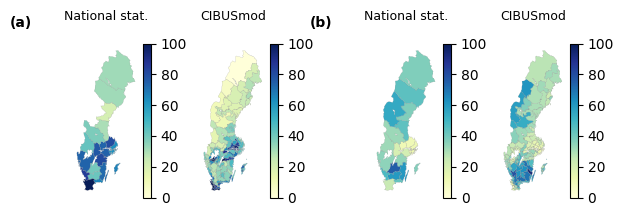

In [96]:
area = (
    session.get_attr('C','area',{'crop':'land_use','region':None})
    .loc[(scn,year),'cropland']
)

fig = plt.figure(figsize=(6, 2))
subfigs = fig.subfigures(1, 2, width_ratios=[1, 1])

# Mineral per ha
subfig = subfigs[0]
axs = subfig.subplots(1, 2)

ax = axs[0]
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)
ax.set_title('National stat.', size=9)
ax.axis('off')

ax = axs[1]
plot_data = (
    session
    .get_attr('C','fertiliser.mineral_N',{'crop':'land_use', 'region':None})
    .loc[(scn,year)]
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
ax.set_title('CIBUSmod', size=9)
ax.axis('off')

# Manure per ha
subfig = subfigs[1]
axs = subfig.subplots(1, 2)

ax = axs[0]
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)
ax.set_title('National stat.', size=9)
ax.axis('off')

ax = axs[1]
plot_data = (
    session
    .get_attr('C','fertiliser.manure_N',{'crop':'land_use', 'MMS':None, 'region':None})
    .loc[(scn,year)]
    .drop('grazing', level='MMS')
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
ax.set_title('CIBUSmod', size=9)
ax.axis('off')

annotate_axs(np.array([f.axes[0] for f in subfigs]))
plt.savefig('figs/Fig7.png', bbox_inches='tight', dpi=300)
plt.show()

#### For organic areas

---------
base year
---------


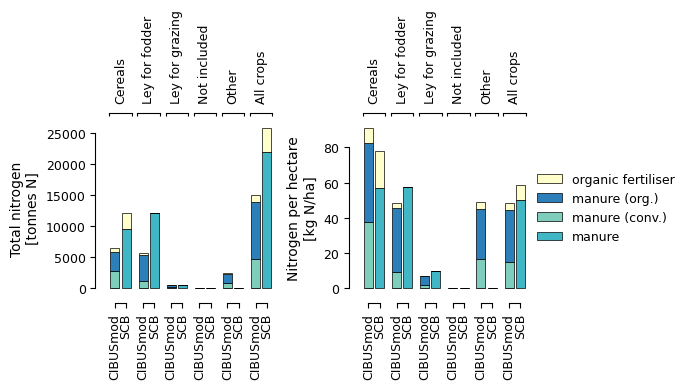

-------------------------
base year (x0 crop areas)
-------------------------


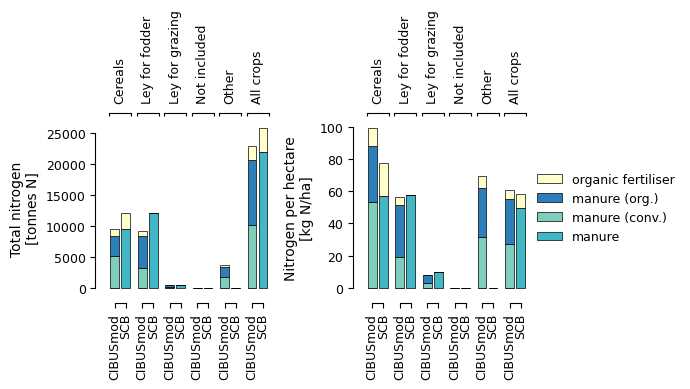

In [156]:
# SCB
# Gödselmedel i jordbruket 2021/22
# Mineral- och stallgödsel till olika grödor samt hantering och lagring av stallgödsel
# MI 30 SM 2302
# Tabell 1.8 - 1.11

scb_organic_tot = pd.Series({
    ('SCB','All crops','organic fertiliser') : 3_850,
    ('SCB','All crops','manure') : 21_975,
    ('SCB','Cereals','organic fertiliser') : 2_557,
    ('SCB','Cereals','manure') : 9_547,
    ('SCB','Ley for fodder','organic fertiliser') : np.nan,
    ('SCB','Ley for fodder','manure') : 12_040,
    ('SCB','Ley for grazing','organic fertiliser') : np.nan,
    ('SCB','Ley for grazing','manure') : 510,
    ('SCB','Not included','organic fertiliser') : np.nan,
    ('SCB','Not included','manure') : np.nan,
    ('SCB','Other','organic fertiliser') : np.nan,
    ('SCB','Other','manure') : np.nan
}).unstack().rename_axis(['source', 'crop_group_fertstat'])

scb_organic_ha = pd.Series({
    ('SCB','All crops','organic fertiliser') : 8.7,
    ('SCB','All crops','manure') : 49.8,
    ('SCB','Cereals','organic fertiliser') : 20.8,
    ('SCB','Cereals','manure') : 56.9,
    ('SCB','Ley for fodder','organic fertiliser') : np.nan,
    ('SCB','Ley for fodder','manure') : 57.6,
    ('SCB','Ley for grazing','organic fertiliser') : np.nan,
    ('SCB','Ley for grazing','manure') : 9.6,
    ('SCB','Not included','organic fertiliser') : np.nan,
    ('SCB','Not included','manure') : np.nan,
    ('SCB','Other','organic fertiliser') : np.nan,
    ('SCB','Other','manure') : np.nan
}).unstack().rename_axis(['source', 'crop_group_fertstat'])
for scn in ['base year', 'base year (x0 crop areas)']:
    print('-'*len(scn), scn, '-'*len(scn), sep='\n')
    # Get data from CIBUSmod
    area = (
        session.get_attr(
            'C',
            'area',
            {'prod_system':None, 'crop':'crop_group_fertstat'}
        )
        .loc[(scn,year),'organic']
    )
    manure = (
        session.get_attr(
            'C',
            'fertiliser.manure_N',
            {'prod_system':None, 'crop':'crop_group_fertstat', 'animal_prod_system':None, 'MMS':None}
        )
        .loc[(scn,year)]
        .drop('grazing', level='MMS')
        .groupby(['prod_system','crop_group_fertstat','animal_prod_system'])
        .sum()
        .unstack()
        .rename(columns={'conventional':'manure (conv.)', 'organic':'manure (org.)'})
        .loc['organic']
    )
    organic_fert = (
        session.get_attr(
            'C','fertiliser.organic_N',
            {'prod_system':None, 'crop':'crop_group_fertstat'}
        )
        .loc[(scn,year),'organic']
        .rename('organic fertiliser')
    )
    
    cbm_tot = pd.concat([manure, organic_fert], axis=1) / 1_000
    cbm_tot.loc['All crops'] = pd.concat([manure, organic_fert], axis=1).drop('Not included').sum() / 1_000
    cbm_tot = pd.concat({'CIBUSmod': cbm_tot}, names=['source'])
    
    cbm_ha = pd.concat([manure, organic_fert], axis=1).fillna(0).div(area, axis=0)
    cbm_ha.loc['All crops'] = pd.concat([manure, organic_fert], axis=1).drop('Not included').sum() / area.drop('Not included').sum()
    cbm_ha = pd.concat({'CIBUSmod': cbm_ha}, names=['source'])
    
    # Combine data
    plot_data_tot = pd.concat([cbm_tot, scb_organic_tot]).sort_index(axis=1)
    plot_data_ha = pd.concat([cbm_ha, scb_organic_ha]).sort_index(axis=1)
    
    # Plot
    from matplotlib.colors import ListedColormap
    
    fig,axs = plt.subplots(1,2, figsize=(7,4))
    ax = axs[0]
    cm.plot.bar(
        plot_data_tot,
        group_levels='crop_group_fertstat',
        cmap = ListedColormap(name='X', colors=['#41b6c4', '#7fcdbb', '#2c7fb8', '#ffffcc']),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        grouplabels_vertical = True,
        ylabel = 'Total nitrogen\n[tonnes N]',
        ax = ax
    )
    ax.legend().set_visible(False)
    
    ax = axs[1]
    cm.plot.bar(
        plot_data_ha,
        group_levels='crop_group_fertstat',
        cmap = ListedColormap(name='X', colors=['#41b6c4', '#7fcdbb', '#2c7fb8', '#ffffcc']),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        grouplabels_vertical = True,
        ylabel = 'Nitrogen per hectare\n[kg N/ha]',
        ax = ax
    )
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, reverse=True, fontsize=9)
    
    plt.tight_layout()
    plt.show()

scn = 'base year'

#### Compared to Einarsson et al (2022)

In [25]:
excr = session.get_attr('a','manure.N_excr','none').loc[[(scn,year)]].rename('excretion')
excr.index = pd.Index(['N'], name='compound')
to_treatment = session.get_attr('a','manure.N_to_treatment','none').loc[[(scn,year)]]
to_treatment.index = pd.Index(['N'], name='compound')
to_spread = (
    session.get_attr('a','manure.N_to_spread','none').loc[[(scn,year)]] +
    session.get_attr('w','organic_fertiliser_N',['feedstock_type']).loc[[(scn,year)], 'manure']
).rename('to spread')
to_spread.index = pd.Index(['N'], name='compound')
loss = (
    session.get_attr('a','manure.N_loss',['compound']).loc[(scn,year)].add(
        session.get_attr('w','losses_N',['feedstock_type', 'compound']).loc[(scn,year), 'manure'],
        fill_value=0
    )
).rename('losses')
appl_loss = pd.concat([
    session.get_attr('c','fertiliser.manure_N_soil_loss','compound').loc[(scn,year)],
    session.get_attr('c','fertiliser.manure_N_application_loss','compound').loc[(scn,year)]
]).rename('application/soil loss')

cibus = pd.concat([excr, loss, to_spread, appl_loss], axis=1).fillna(0).rename_axis('stage', axis=1)/1_000_000
cibus = pd.concat({'CIBUSmod': cibus}, names=['source'], axis=1)

Einarsson_data = {
    'index': ['N', 'N2', 'N2O-N', 'NH3-N', 'NOx-N'],
    'columns': [('Einarsson et al (2022)', i) for i in ['excretion', 'losses', 'to spread', 'application/soil loss']],
    'data': [[134.02, 0,         39.82+72.45, 0],
             [0,      3.92,      0,           0],
             [0,      0.51,      0,           0.69+72.45*0.01],
             [0,      7.31+9.88, 0,           3.10+12.69],
             [0,      0.13,      0,           0]],
    'index_names': ['compound'],
    'column_names': ['source', 'stage']
}
Einarsson = pd.DataFrame.from_dict(Einarsson_data, orient='tight')

plot_data = pd.concat([cibus, Einarsson], axis=1)

In [26]:
table_data = plot_data.stack('stage').replace({0:np.nan}).dropna(how='all').reorder_levels([1,0]).sort_index()
table_data['Diferance'] = (table_data['CIBUSmod'] - table_data['Einarsson et al (2022)']) / table_data['Einarsson et al (2022)'] * 100
display(table_data.style.format(precision=2))

In [27]:
# Share of excretion lost
plot_data.sum().groupby('source').apply(lambda x: x.loc[(slice(None),'losses')].sum()/x.loc[(slice(None),'excretion')].sum()*100)

source
CIBUSmod                  17.335028
Einarsson et al (2022)    16.228921
dtype: float64

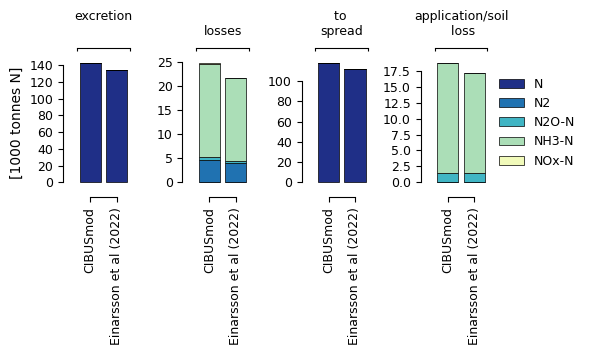

In [28]:
fig, axs = plt.subplots(1,4, figsize=(6,3.5))

for i, s in enumerate(plot_data.columns.unique('stage')):
    ax = axs[i]
    d = plot_data.T.loc[(slice(None),s),:]
    cm.plot.bar(
        d,
        stacked = True,
        group_levels='stage',
        ylabel='[1000 tonnes N]' if i==0 else '',
        ax = ax,
        **bar_style
    )
    if i < len(axs) - 1:
        ax.legend().remove()
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

#### N inputs to conventional and organic cropland

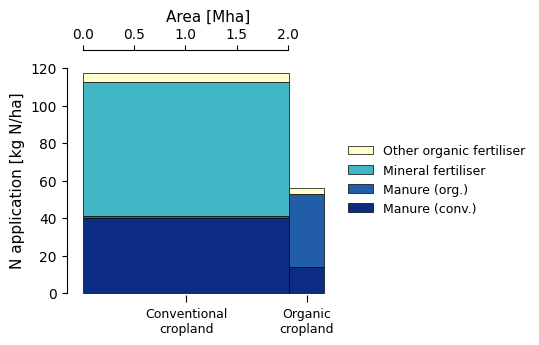

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.603039,0.677202,60.118016,3.913987
Organic\ncropland,24.239805,69.298769,NaN,5.862182


In [29]:
mi = (
    session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
)
ma = (
    session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
    .unstack()
    .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
)

oo = (
    session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
)

ar = (
    session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
)

plot_data = pd.concat([
    ma.div(ar, axis=0),
    mi.div(ar, axis=0).rename('Mineral fertiliser'),
    oo.div(ar, axis=0).rename('Other organic fertiliser'),
    ar.rename('area')/1_000_000
], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})

from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(3.3,3))

cm.plot.marimekko(
    plot_data.fillna(0),
    ax=ax,
    x_column='area',
    cmap=cust_cmap,
    sort_categories=False,
    xlim_pad = 0.05,
    ylim_pad = 0.04,
    xcategorylabels_rotation=0,
    xcategorylabels_halign='center',
    ylabel='N application [kg N/ha]',
    xlabel='Area [Mha]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)

plt.show()

display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)

#### Manure P application
A maximum of 22 kg P per hectare and year in the form of applied manure is allowed as a 5-year average in Sweden

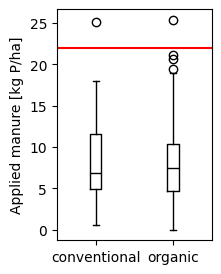

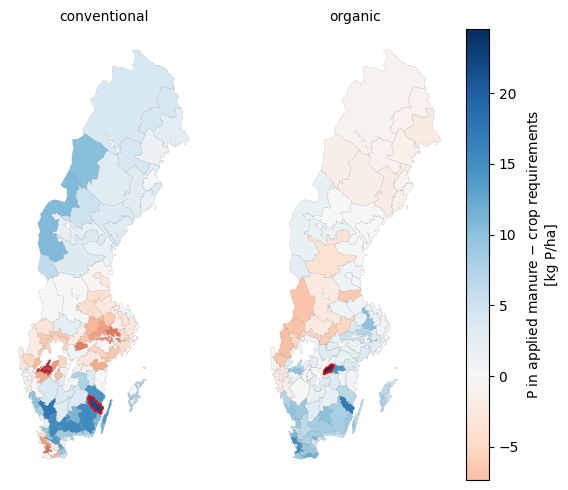

In [165]:
plot_data = (
    session.get_attr('C', 'fertiliser.manure_P',{'MMS':None,'crop':'land_use','prod_system':None,'region':None})
    .drop('grazing', level='MMS', axis=1)
    .T.groupby(['land_use','prod_system','region']).sum().T
    /
    session.get_attr('C', 'area',{'crop':'land_use','prod_system':None,'region':None})
).loc[('base year','2020'),'cropland'].unstack('prod_system')

plot_data2 = (
    (session.get_attr('C', 'fertiliser.manure_P',{'MMS':None,'crop':'land_use','prod_system':None,'region':None})
    .drop('grazing', level='MMS', axis=1)
    .T.groupby(['land_use','prod_system','region']).sum().T
    -
    session.get_attr('C', 'fertiliser.P_req',{'crop':'land_use','prod_system':None,'region':None}))
    /
    session.get_attr('C', 'area',{'crop':'land_use','prod_system':None,'region':None})
).loc[('base year','2020'),'cropland'].unstack('prod_system')

fig, ax = plt.subplots(figsize=(2,3))
plot_data.plot.box(ax=ax, color='black', ylabel='Applied manure [kg P/ha]')
ax.axhline(22, color='red')
plt.show()

fig, axs = plt.subplots(1,2, figsize=(6,5), gridspec_kw={'width_ratios':[1,1.6]})
lim = plot_data2.max().max()
for i, ax in enumerate(axs):
    cm.plot.map_from_series(
        plot_data2.iloc[:,i],
        cmap='RdBu',
        edgecolor='grey',
        cmap_zero_midpoint='shrink',
        ax=ax,
        vmax=lim,
        legend=False
    )
    cm.plot.map_from_series(
        (plot_data.iloc[:,i] > 22).replace({False:np.nan}),
        facecolor='none',
        edgecolor='red',
        linewidth=1,
        ax=ax,
        legend=False
    )
    ax.axis('off')
    ax.set_title(plot_data.columns[i], size=10)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('P in applied manure $\minus$ crop requirements\n[kg P/ha]', fontsize=10)
plt.tight_layout()
plt.show()

### Waste treatment

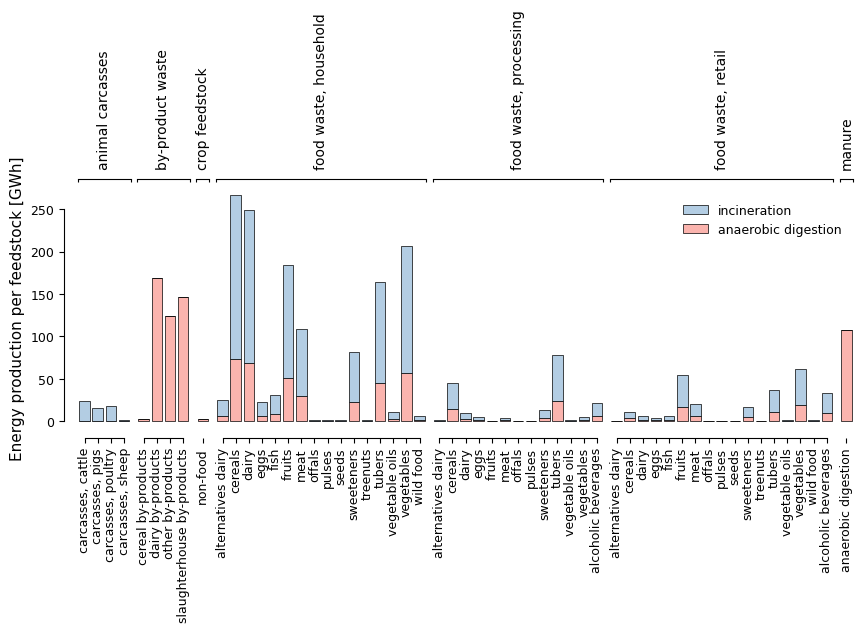

In [31]:
plot_data = (
    session.get_attr('w', 'energy_prod', ['feedstock_type', 'feedstock_group', 'treatment'])
    .loc[(scn,year)]
    .unstack()
)/1000000 # GWh

fig, ax = plt.subplots(figsize=(10,3))
cm.plot.bar(
    plot_data,
    group_levels='feedstock_type',
    ticklabels_fontsize=9,
    grouplabels_vertical=True,
    cmap='Pastel1',
    ylabel='Energy production per feedstock [GWh]'
)
plt.show()

In [32]:


print('2016 (alla anläggningar)')
tot_2016 = 2_018 #GWh
print('food waste:',tot_2016 * 11/100,'GWh')
print('manure:',tot_2016 * 19/100,'GWh')
print('food industry:',tot_2016 * 10/100,'GWh')

print('\n2020 (alla anläggningar)')
tot_2020 = 2_161 #GWh
print('food waste:',tot_2020 * 21/100,'GWh')
print('manure:',tot_2020 * 11/100,'GWh')
print('food industry:',tot_2020 * 7/100,'GWh')

print('\n2022 (samrötning)')
tot_2022 = 1_145 #GWh
print('food waste:',round(tot_2022 * ((426*148)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('manure:',round(tot_2022 * ((661*26)/(426*148+661*26+293*66+186*120+204*100))),'GWh')
print('food industry:',round(tot_2022 * ((293*66)/(426*148+661*26+293*66+186*120+204*100))),'GWh')

print('\nCIBUSmod energy production [GWh]')
print(session.get_attr('w','energy_prod').loc[(scn,year)].groupby(['treatment','feedstock_type']).sum()/1000000)

print(
    '',
    '---------------------------',
    'Total N in feedstocks to AD',
    '---------------------------',
    sep='\n'
)
print(
    'Swe IIR 2023 Table 6-11 (avg 2016-2020):',
    round((13_139+12_934+13_880+15_119+15_017)/5),
    't N'
)
print(
    'CIBUSmod:',
    round(session.get_attr('w','feedstock_N').loc[(scn,year)].xs('anaerobic digestion', level='treatment').sum()/1000),
    't N'
)

2016 (alla anläggningar)
food waste: 221.98 GWh
manure: 383.42 GWh
food industry: 201.8 GWh

2020 (alla anläggningar)
food waste: 453.81 GWh
manure: 237.71 GWh
food industry: 151.27 GWh

2022 (samrötning)
food waste: 507 GWh
manure: 138 GWh
food industry: 156 GWh

CIBUSmod energy production [GWh]
treatment            feedstock_type        
anaerobic digestion  by-product waste          442.122537
                     crop feedstock              2.271180
                     food waste, household     374.382815
                     food waste, processing     58.131599
                     food waste, retail         79.284509
                     manure                    107.596240
incineration         animal carcasses           59.724604
                     food waste, household     988.581213
                     food waste, processing    128.661009
                     food waste, retail        175.478141
Name: (base year, 2020), dtype: float64

---------------------------
Total N i

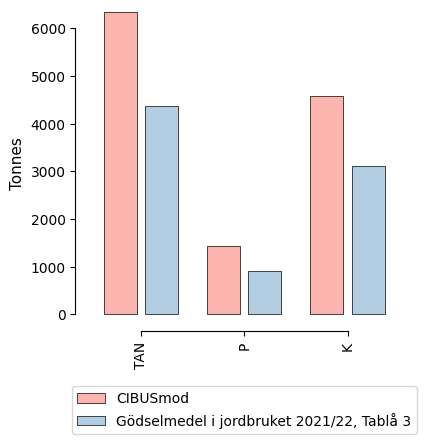

In [33]:

df_Cm = pd.concat([
    session.get_attr('w','organic_fertiliser_TAN',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_P',['treatment']).loc[(scn,year)],
    session.get_attr('w','organic_fertiliser_K',['treatment']).loc[(scn,year)]
]).rename('CIBUSmod')/1000
df_Cm.index = ['TAN','P','K']

# "Biogödsel totalt" according to statistics (Gödselmedel i jordbruket 2021/22, Tablå 3)
df_stat = pd.Series({
    'TAN' : 4370,
    'P' : 910,
    'K' : 3110
}).rename('Gödselmedel i jordbruket 2021/22, Tablå 3')

df = pd.concat([df_Cm,df_stat], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(df, stacked=False, cmap='Pastel1', ylabel='Tonnes', ax=ax)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize=10)
plt.show()

### Energy use

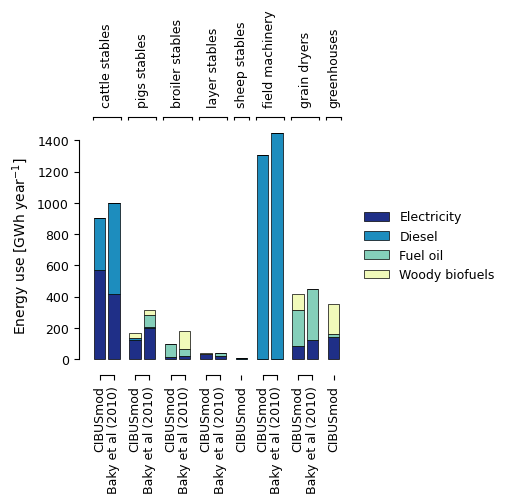

In [72]:
plot_data = (
    session.get_attr('A','energy_use',['species','breed','energy_source'])
    .loc[(scn,year)]
    .rename({'beef':'all','dairy':'all',
            'cold blooded horses':'all','ponies and Icelandic horses':'all','riding horses':'all','trotters and racehorses':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['Electricity','Diesel','Fuel oil','Woody biofuels']]
    /1000000
)
idx = pd.MultiIndex.from_tuples(
    [(f'{sp if sp != "poultry" else br} stables', 'CIBUSmod') for sp,br in plot_data.index],
    names=['category','source']
)
plot_data.index = idx
plot_data = plot_data.reindex(idx, fill_value=0)

plot_data.loc[('field machinery','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),'field machinery'].rename({'Biodiesel':'Diesel'})
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('grain dryers','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['grain dryers', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('greenhouses','CIBUSmod'),:] = (
    session.get_attr('C','energy_use',['activity','energy_source'])
    .loc[(scn,year),['greenhouses', 'grain dryers auxiliary energy']]
    .groupby('energy_source').sum()
    /1000000
)

plot_data.loc[('cattle stables','Baky et al (2010)'),:]  = [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pigs stables','Baky et al (2010)'),:]     = [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broiler stables','Baky et al (2010)'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layer stables','Baky et al (2010)'),:]   = [      19,       0.2,     19,       0 ]
plot_data.loc[('field machinery','Baky et al (2010)'),:] = [       0,      1449,      0,       0 ]
plot_data.loc[('grain dryers','Baky et al (2010)'),:] =    [     125,         0,      325,     0 ]

plot_data = plot_data.fillna(0)

fig, ax = plt.subplots(figsize=(3.2,3))
cm.plot.bar(plot_data, group_levels='category', ylabel='Energy use [GWh year$^{-1}$]', grouplabels_vertical=True, ax=ax, **bar_style)
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=9, frameon=False)
plt.savefig('figs/Fig8.png', dpi=300, bbox_inches='tight')
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

In [35]:
session.get_attr('c', 'energy_use')

crop                            Barley, spring                               \
prod_system                       conventional                                
region                                    1011                                
activity                       field machinery                 grain dryers   
energy_source                        Biodiesel        Diesel       Fuel oil   
scn                       year                                                
base year                 2020    44661.538478  1.503976e+06  478211.398117   
base year (x0 crop areas) 2020    53263.669972  1.793653e+06  574107.954656   
base year (sp=0.2)        2020    45225.128406  1.522955e+06  483238.751821   
base year (sp=0.8)        2020    47234.363598  1.590616e+06  507472.733900   

crop                                                                         \
prod_system                                                                   
region                                                                        
activity                                      grain dryers auxiliary energy   
energy_source                  Woody biofuels                   Electricity   
scn                       year                                                
base year                 2020  209605.645279                 182439.538719   
base year (x0 crop areas) 2020  251638.226878                 219024.454111   
base year (sp=0.2)        2020  211809.193168                 184357.494030   
base year (sp=0.8)        2020  222431.230768                 193602.853988   

crop                                                                         \
prod_system                                                                   
region                                     111                                
activity                       field machinery                 grain dryers   
energy_source                        Biodiesel        Diesel       Fuel oil   
scn                       year                                                
base year                 2020    55540.999254  1.870342e+06  390915.178211   
base year (x0 crop areas) 2020    71512.043112  2.408167e+06  505075.717830   
base year (sp=0.2)        2020    58348.535553  1.964886e+06  410580.913824   
base year (sp=0.8)        2020    59651.314227  2.008757e+06  420265.780719   

crop                                                                         \
prod_system                                                                   
region                                                                        
activity                                      grain dryers auxiliary energy   
energy_source                  Woody biofuels                   Electricity   
scn                       year                                                
base year                 2020  171342.691748                 149135.685749   
base year (x0 crop areas) 2020  221380.590607                 192688.382882   
base year (sp=0.2)        2020  179962.413527                 156638.241623   
base year (sp=0.8)        2020  184207.403887                 160333.056627   

crop                            ...   Wheat, winter                 \
prod_system                     ...         organic                  
region                          ...             912                  
activity                        ... field machinery                  
energy_source                   ...       Biodiesel         Diesel   
scn                       year  ...                                  
base year                 2020  ...    10291.373372  346561.779848   
base year (x0 crop areas) 2020  ...    14831.825978  499461.424977   
base year (sp=0.2)        2020  ...    11602.754303  390722.504873   
base year (sp=0.8)        2020  ...     5962.617945  200791.032739   

crop                                                          \
prod_system                                                    
region 

In [36]:
(
    session.get_attr('A','energy_use','energy_source').add(
        session.get_attr('C','energy_use','energy_source'),
        fill_value=0
    )
    .loc[(scn,year)]
    /1_000_000
)

energy_source
Biodiesel             37.700110
Diesel              1622.557111
District heating      23.961720
Electricity          880.625560
Fuel oil             339.098147
Geothermal             2.581309
Natural gas           28.032600
Woody biofuels       331.645896
Name: (base year, 2020), dtype: float64

In [37]:
plot_data.xs('CIBUSmod', level='source').sum()

energy_source
Electricity        966.113157
Diesel            1660.257222
Fuel oil           339.098147
Woody biofuels     331.645896
dtype: float64

In [38]:
plot_data.xs('CIBUSmod', level='source').sum().sum()

3297.114421401418

### Use of by-products

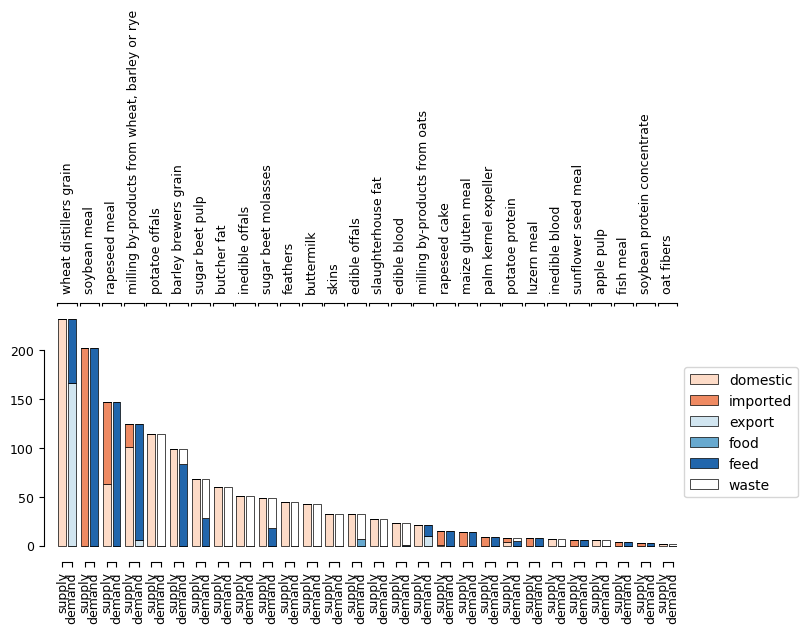

In [39]:
use = pd.concat([
    
    session.get_attr('D', 'by_prod_demand', ['by_prod', 'demand']).loc[(scn,year)].unstack(fill_value=0),
    
    session.get_attr('A', 'feed.by_product_demand', 'by_prod')
    .loc[(scn,year)]
    .rename('feed'),

    session.get_attr('D', 'by_prod_to_waste', 'by_prod').loc[(scn,year)]
    .rename('waste')
    
], axis=1).fillna(0).rename_axis('origin', axis=1)

supply = (
    session.get_attr('D', 'by_products', ['by_prod', 'origin'])
    .loc[(scn,year)]
    .unstack()
    .fillna(0)
)

plot_data = pd.concat([
    pd.concat({'supply': 
       supply
      }, names=['flow'], axis=1),
    
    pd.concat({'demand': 
       use
      }, names=['flow'], axis=1)
], axis=1).stack('flow').sort_index(level='flow', ascending=False).sort_index(level='by_prod', sort_remaining=False).fillna(0)/1000000

from matplotlib.colors import ListedColormap
colors = ['#fddbc7', '#ef8a62', '#d1e5f0', '#67a9cf', '#2166ac', '#ffffff']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(1,1, figsize=(8,3))
ax, axgs = cm.plot.bar(
    plot_data.drop('whey'),
    ax=ax,
    cmap = cust_cmap,
    group_levels='by_prod',
    sort_groups=True,
    grouplabels_vertical=True,
    group_spacing = 0.3,
    ticklabels_fontsize = 9,
    grouplabels_fontsize = 9,
    ylabel_fontsize = 10,
    xlabel_fontsize = 10
)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

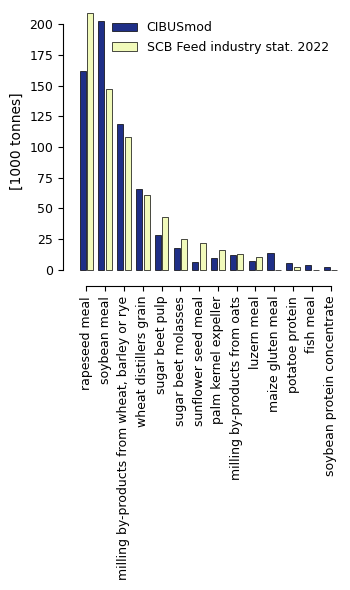

,CIBUSmod,SCB Feed industry stat. 2022,dif,dif%
by_prod,,,,
soybean meal,202,148,55,37
rapeseed meal,162,209,-47,-23
"milling by-products from wheat, barley or rye",119,108,11,10
wheat distillers grain,66,60,5,9
sugar beet pulp,28,43,-15,-35
sugar beet molasses,18,25,-8,-31
milling by-products from oats,12,13,-1,-9
palm kernel expeller,9,16,-7,-42
luzern meal,7,11,-3,-31


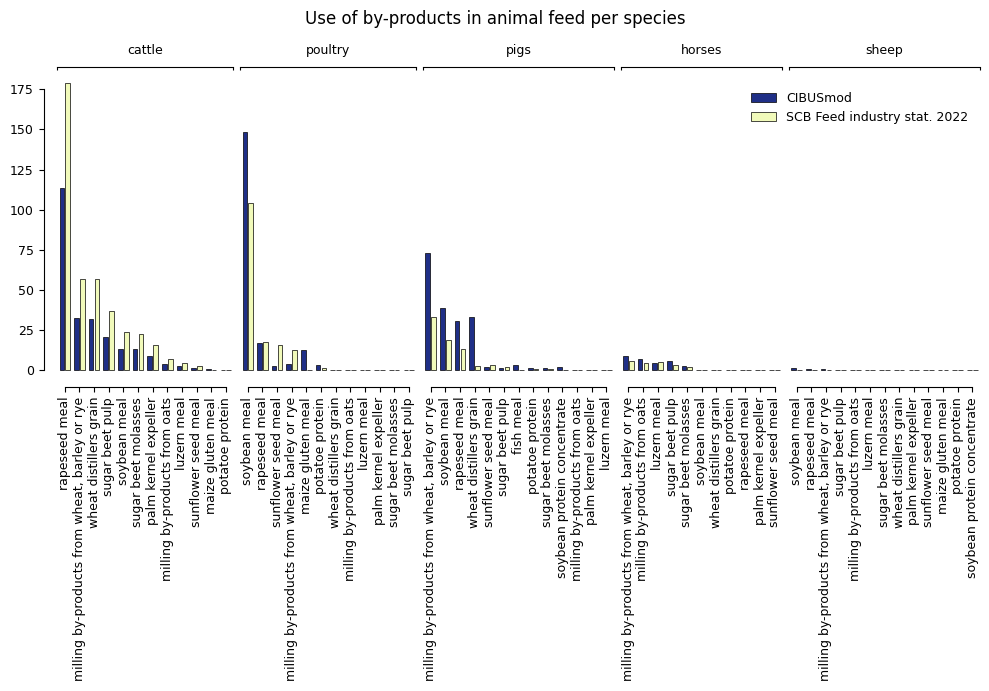

In [184]:
data = (
    session.get_attr('A','feed.by_product_demand')
    .loc[(scn,year)]
    .rename({'rapeseed cake' : 'rapeseed meal'})
    .groupby(['species','by_prod']).sum()
    .rename('CIBUSmod')
)/1000000

SCB_2022_feed_industry_stat = pd.Series({
    
    ('cattle','wheat distillers grain') : 56.803,
    ('cattle','rapeseed meal') : 178.628,
    ('cattle','milling by-products from wheat, barley or rye') : 57.085,
    ('cattle','sugar beet pulp') : 36.933,
    ('cattle','sugar beet molasses') : 22.689,
    ('cattle','soybean meal') : 23.656,
    ('cattle','palm kernel expeller') : 15.770,
    ('cattle','milling by-products from oats') : 7.277,
    ('cattle','luzern meal') : 4.850,
    ('cattle','sunflower seed meal') : 2.427,
    ('cattle','potatoe protein') : 0.166,

    ('horses','wheat distillers grain') : 0.199,
    ('horses','rapeseed meal') : 0.004,
    ('horses','milling by-products from wheat, barley or rye') : 5.745,
    ('horses','milling by-products from oats') : 4.646,
    ('horses','sugar beet pulp') : 3.495,
    ('horses','sugar beet molasses') : 1.812,
    ('horses','soybean meal') : 0.500,
    ('horses','palm kernel expeller') : 0.000,
    ('horses','luzern meal') : 5.355,
    ('horses','sunflower seed meal') : 0.000,
    ('horses','potatoe protein') : 0.016,

    ('pigs','wheat distillers grain') : 3.007, # A lot fed wet not through feed industry?
    ('pigs','rapeseed meal') : 13.057,
    ('pigs','milling by-products from wheat, barley or rye') : 33.011,
    ('pigs','milling by-products from oats') : 0.467,
    ('pigs','barley brewers grain') : np.nan, # Not in data, not going through feed industry??
    ('pigs','whey') : np.nan, # Not in data, not going through feed industry??
    ('pigs','sugar beet pulp') : 2.314,
    ('pigs','sugar beet molasses') : 0.767,
    ('pigs','soybean meal') : 19.069,
    ('pigs','palm kernel expeller') : 0.065,
    ('pigs','luzern meal') : 0.116,
    ('pigs','sunflower seed meal') : 3.581,
    ('pigs','potatoe protein') : 0.864,

    ('poultry','wheat distillers grain') : 0.489,
    ('poultry','rapeseed meal') : 17.796,
    ('poultry','milling by-products from wheat, barley or rye') : 12.408,
    ('poultry','milling by-products from oats') : 0.440,
    ('poultry','sugar beet pulp') : 0.000,
    ('poultry','sugar beet molasses') : 0.000,
    ('poultry','soybean meal') : 104.370,
    ('poultry','palm kernel expeller') : 0.000,
    ('poultry','luzern meal') : 0.236,
    ('poultry','sunflower seed meal') : 15.493,
    ('poultry','potatoe protein') : 1.202,
    
}).rename('SCB Feed industry stat. 2022').rename_axis(['species','by_prod'])

plot_data = pd.concat([data, SCB_2022_feed_industry_stat], axis=1)

# Drop whey and barley brewers grain as these are not going through feed industry???
plot_data = plot_data.drop('whey', level='by_prod')
plot_data = plot_data.drop('barley brewers grain', level='by_prod')

fig, ax = plt.subplots(1,1, figsize=(3.6,6))
ax, axgs = cm.plot.bar(plot_data.groupby('by_prod').sum(), ax=ax, stacked=False, ylabel='[1000 tonnes]', sort_xlabels=True, **bar_style)
plt.tight_layout()
plt.savefig('figs/Fig5.png', dpi=300)
plt.show()

t = plot_data.groupby('by_prod').sum()
t['dif'] = t['CIBUSmod'] - t['SCB Feed industry stat. 2022']
t['dif%'] = t['dif']/t['SCB Feed industry stat. 2022']*100
display(t.replace({np.inf:np.nan}).dropna().sort_values('CIBUSmod', ascending=False).style.format(precision=0))

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax, axgs = cm.plot.bar(plot_data, ax=ax, stacked=False, group_levels='species', sort_xlabels=True, sort_groups=True, **bar_style)
plt.suptitle('Use of by-products in animal feed per species')
plt.tight_layout()
plt.show()

### Feed rations

In [41]:
table_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', ['species', 'breed', 'animal', 'feed']).loc[(scn,year)]
    .unstack(['species','breed','animal'], fill_value=0)
    /
    session.get_attr('AnimalHerd', 'heads', ['species', 'breed', 'animal']).loc[(scn,year)]
)

table_data.loc['total',:] = table_data.sum()

In [42]:

for sel in ['cattle','sheep','pigs','horses','poultry']:
    str = f'| {sel} [kg DM/head] |'
    print('-'*len(str),str,'-'*len(str),sep='\n')
    display(
        table_data.xs(sel, axis=1)
        .replace({0:np.nan}).dropna(how='all').fillna(0)
        .style.format(precision=1, thousands=" ", decimal=".",)
    )

-----------------------
| cattle [kg DM/head] |
-----------------------


----------------------
| sheep [kg DM/head] |
----------------------


---------------------
| pigs [kg DM/head] |
---------------------


-----------------------
| horses [kg DM/head] |
-----------------------


------------------------
| poultry [kg DM/head] |
------------------------


#### Milk to calves

In [43]:
milk_per_calf = (
    session.get_attr('a','milk_to',['breed']).loc[(scn,year)] /
    (session.get_attr('a','slaughtered_n',['species','breed']) +
     session.get_attr('a','lost_n',['species','breed'])).loc[(scn,year),'cattle']
)
milk_per_cow = (
    session.get_attr('a','milk_to',['breed']).loc[(scn,year)] /
    session.get_attr('a','heads',['species','animal','breed']).loc[(scn,year),('cattle','cows')]
)
milk_per_calf_per_day = milk_per_calf / [213, 63*0.8+84*0.2] # Weaning ages for [beef, dairy]
print('Milk to calves:')
for br in milk_per_calf.index:
    print(f'{br.capitalize()}: {milk_per_calf.loc[br]:,.0f} kg per born calf \
| {milk_per_cow.loc[br]:,.0f} kg per cow per year \
| {milk_per_calf_per_day.loc[br]:.1f} kg per calf per day')

share_of_milk_dairy = (
    session.get_attr('a','milk_to',['breed','prod_system']).loc[(scn,year),'dairy'] /
    (session.get_attr('a','milk_to',['breed','prod_system']).loc[(scn,year),'dairy'] +
     session.get_attr('a','production',['animal_prod','breed','prod_system']).loc[(scn,year),('milk','dairy')])
) * 100
print('\nShare of milk to calves (dairy):')
for ps in share_of_milk_dairy.index:
    print(f'{ps.capitalize()}: {share_of_milk_dairy.loc[ps]:.2f}%')

Milk to calves:
Beef: 1,966 kg per born calf | 1,998 kg per cow per year | 9.2 kg per calf per day
Dairy: 468 kg per born calf | 456 kg per cow per year | 7.0 kg per calf per day

Share of milk to calves (dairy):
Conventional: 4.24%
Organic: 6.73%


#### Organic vs conventional

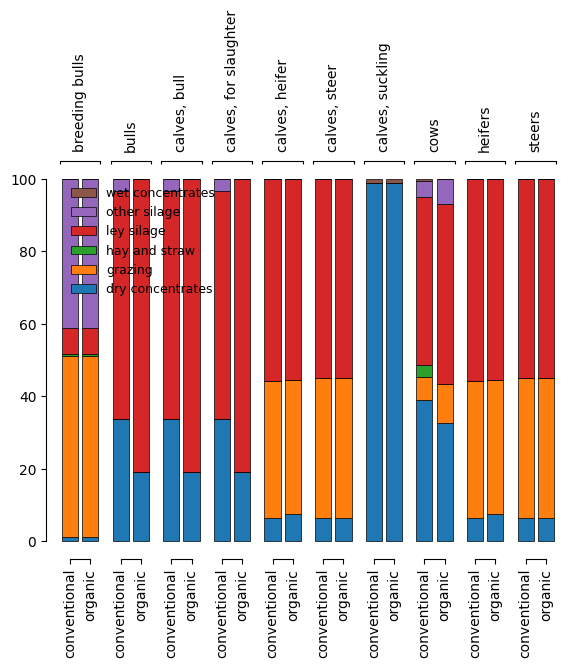

In [44]:
plot_data = (
    session.get_attr('AnimalHerd', 'feed.consumption', {'species':None, 'breed':None, 'prod_system':None, 'animal':None, 'feed':'feed_group'}).loc[(scn,year)]
    .unstack(['species','breed','prod_system','animal'], fill_value=0)
    /
    session.get_attr('AnimalHerd', 'heads', {'species':None, 'breed':None, 'prod_system':None, 'animal':None}).loc[(scn,year)]
).T

plot_data = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

fig,ax = cm.plot.bar(
    plot_data.loc[('cattle','dairy')],
    group_levels='animal',
    grouplabels_vertical=True
)

### Forage and pasture use per livestock system

In [45]:
table_data = session.get_attr('AnimalHerd', 'feed.demand', ['feed', 'species', 'breed', 'animal']).loc[(scn,year)]
table_data = (
    table_data
    .loc['grazing']
    /
    table_data
    .loc[['grazing', 'hay', 'ley silage, 1st cut', 'ley silage, regrowth', 'maize silage', 'other silage', 'straw']]
    .groupby(['species','breed','animal'])
    .sum()
    * 100
).fillna(0)

table_data.rename('% grazing').to_frame().style \
.format(precision=1, decimal=".",)

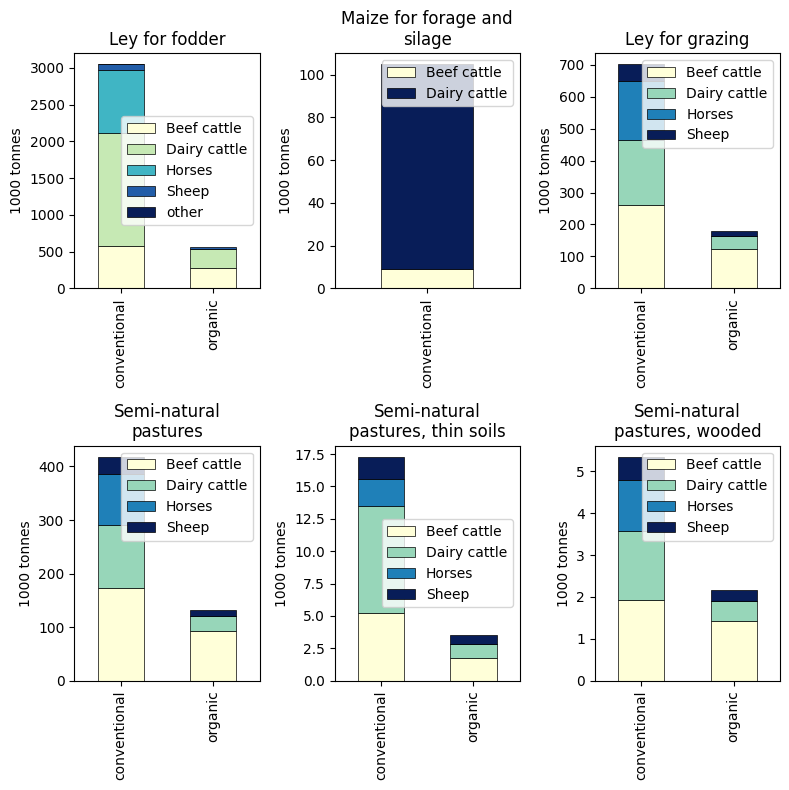

In [46]:
from textwrap import wrap
fig, axs = plt.subplots(2,3, figsize=(8,8))

for ax, cr in zip(
    axs.flatten(),
    ['Ley for fodder', 'Maize for forage and silage', 'Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']
):
    plot_data = (
        session.get_attr('c','production_per_use')
        .loc[(scn,year),cr]
        .groupby(['prod_system','demand'])
        .sum()
        .replace({0:np.nan})
        .dropna()
        .unstack()
    )/1000000
    plot_data.columns = ['Dairy cattle' if 'cattle, dairy' in c else 'Beef cattle' if 'cattle, beef' in c else 'Horses' if 'horses' in c else 'Sheep' if 'sheep' in c else 'other' for c in plot_data.columns]
    plot_data = plot_data.T.groupby(level=0).sum().T
    
    plot_data.plot(**pd_bar_style, stacked=True, ax=ax)
    ax.set_title('\n'.join(wrap(cr, 20)))
    ax.set_ylabel('1000 tonnes')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Crop areas (deviation from x0)

#### Total crop areas

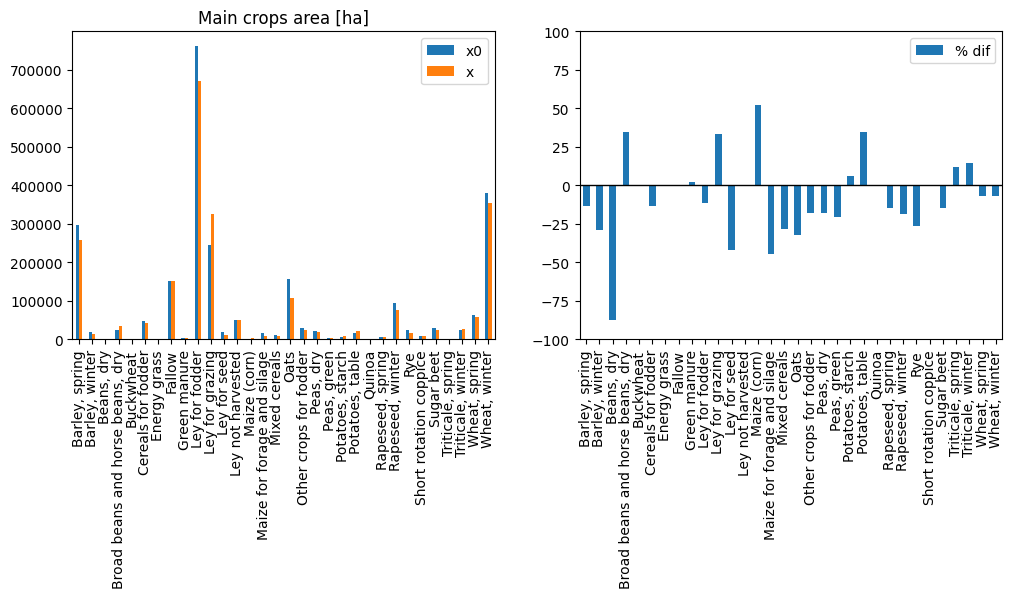

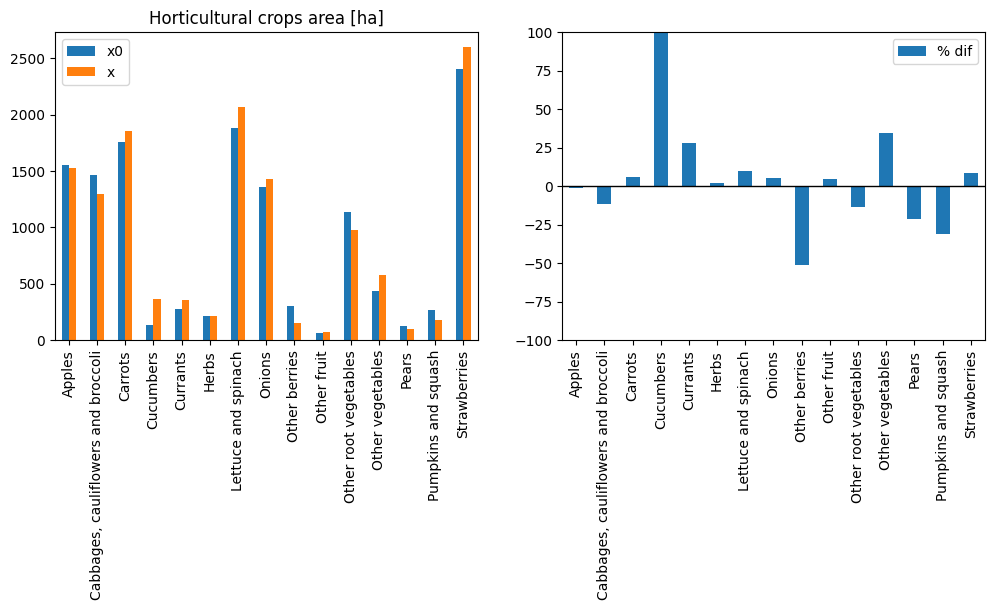

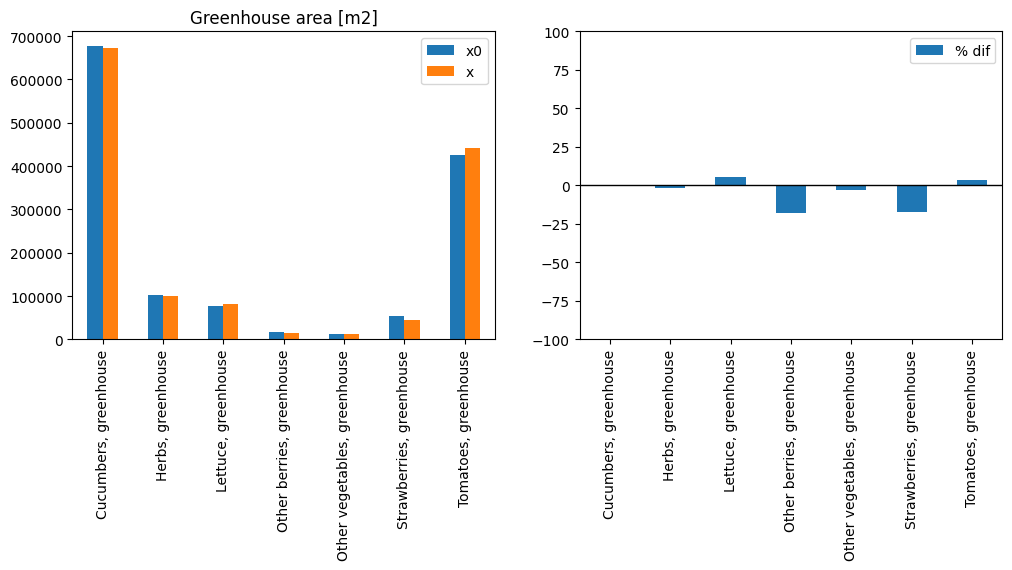

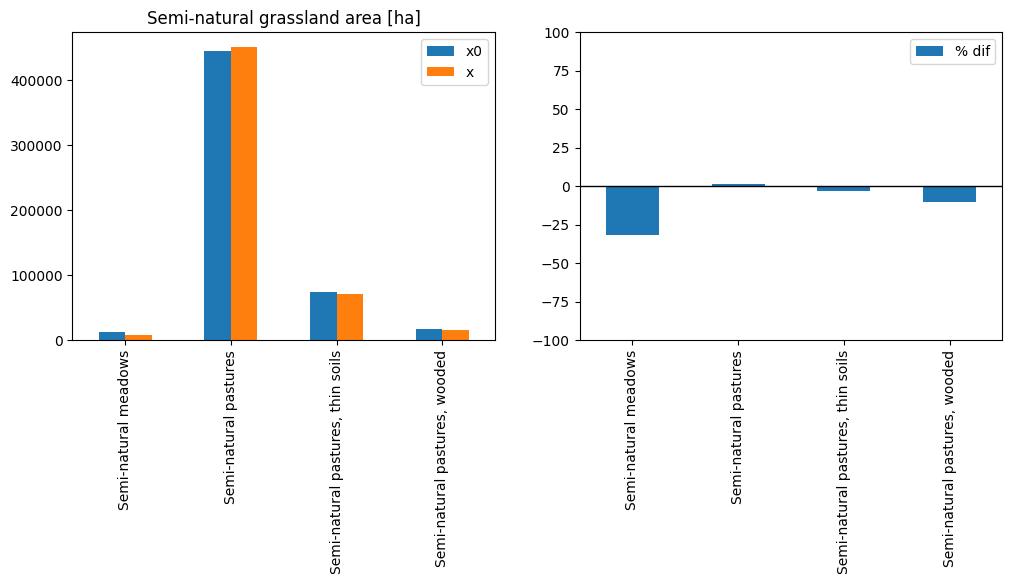

In [47]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['dif'] = plot_data.apply(lambda x:(x['x']-x['x0']), axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

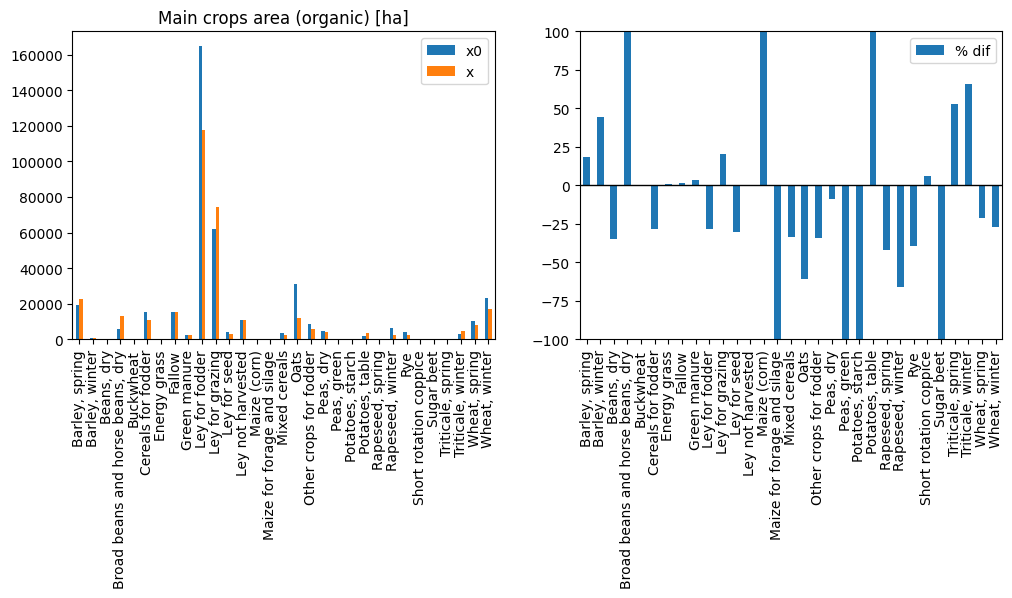

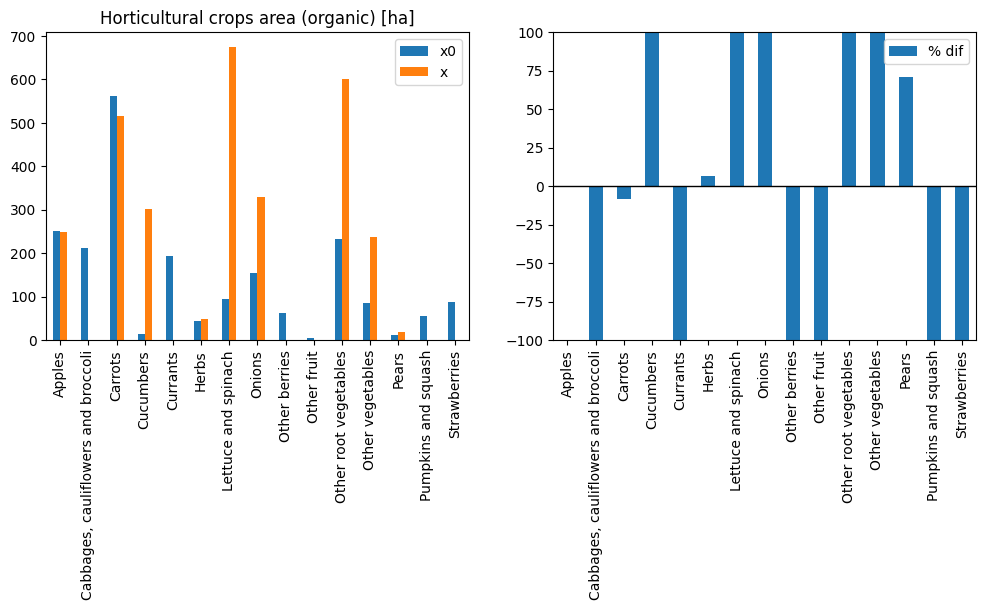

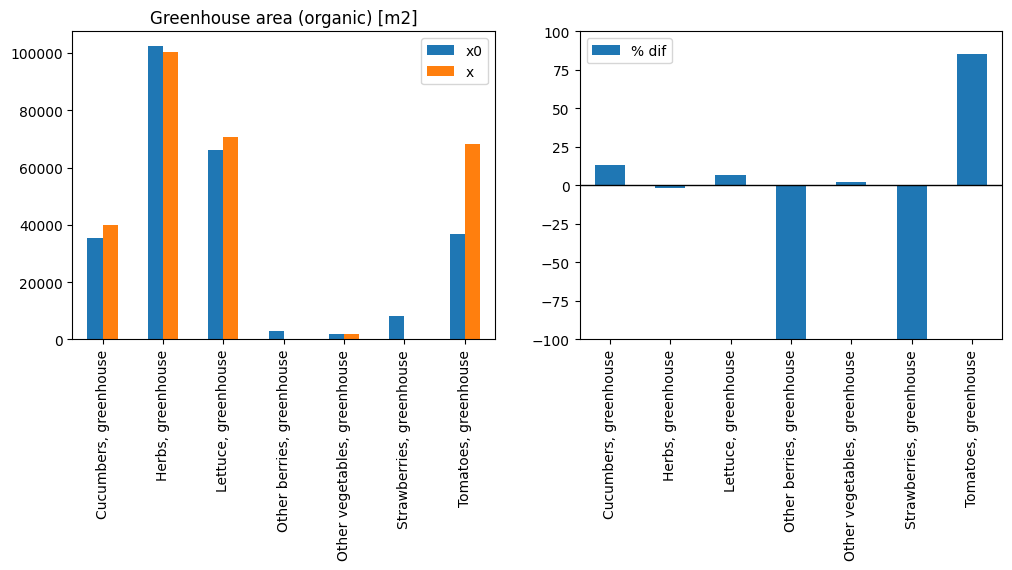

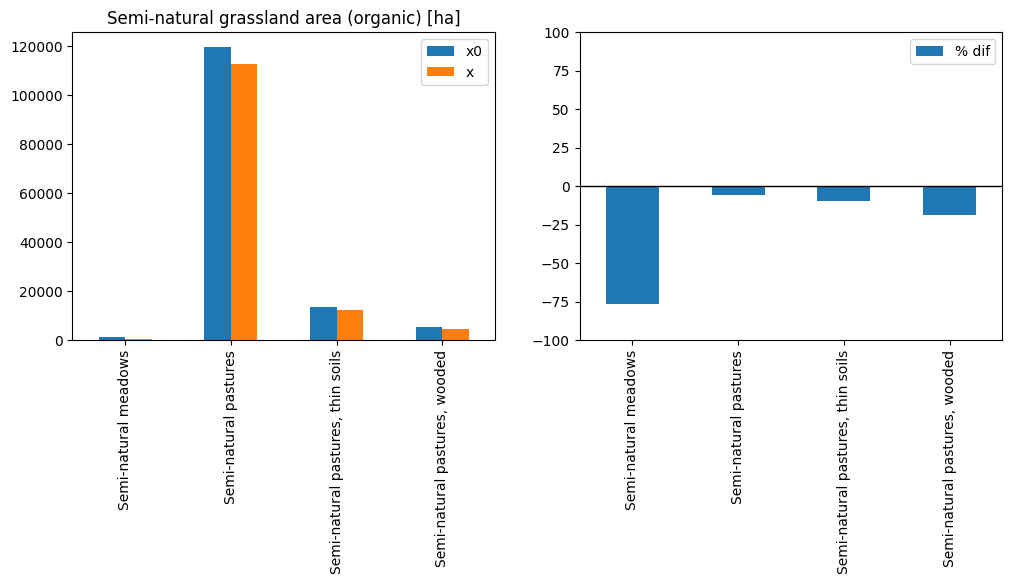

In [48]:
plot_data = pd.concat([
    session.get_attr('C','area',['crop','prod_system']).loc[(scn,year)].rename('x'),
    session.get_attr('R','x0_crops',['crop','prod_system']).loc[(scn,year)].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

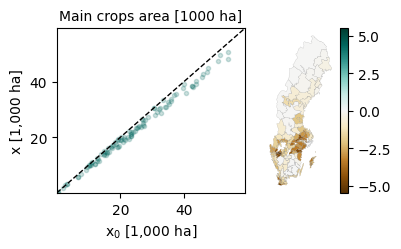

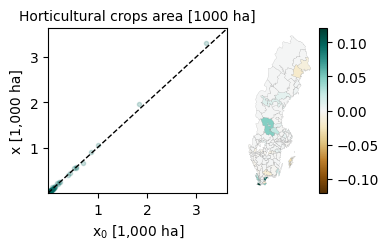

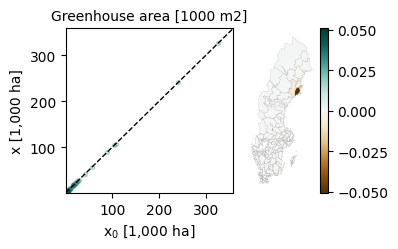

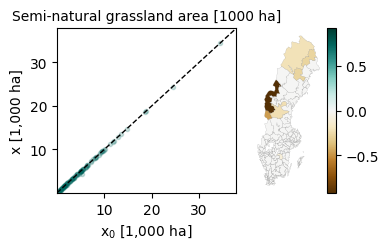

In [186]:
scns = ['base year']#, 'base year (sp=0.2)', 'base year (sp=0.8)']

plot_data_ = (
    pd.concat([
        session.get_attr('C','area',['crop','region']).droplevel('year').loc[scns].rename(lambda x: x.replace('base year', 'x')).T,
        session.get_attr('R','x0_crops',['crop','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)/1000

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [1000 ha]' : cr,
    'Horticultural crops area [1000 ha]' : hr,
    'Greenhouse area [1000 m2]' : gh,
    'Semi-natural grassland area [1000 ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])

    fig, axs = plt.subplots(1,2, figsize=(4,2.6), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    ax=axs[0]
    lim_min = plot_data[['x0','x']].replace({0:np.nan}).min().min() * 0.1
    lim_max = plot_data[['x0','x']].max().max() * 1.1
    plot_data.plot(x='x0', y='x', ax=ax,
                   # loglog=True,
                   xlim = (lim_min,lim_max), ylim=(lim_min,lim_max),
                   linestyle='', marker='.', color='#01665e', alpha=0.2, legend=False)
    ax.axline((0,0),(1,1), color='black', linestyle='--', linewidth=1)
    ax.set_title(p, size=10)
    ax.set_xlabel('x$_{0}$ [1,000 ha]')
    ax.set_ylabel('x [1,000 ha]')
    
    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

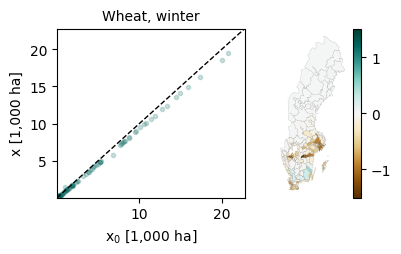

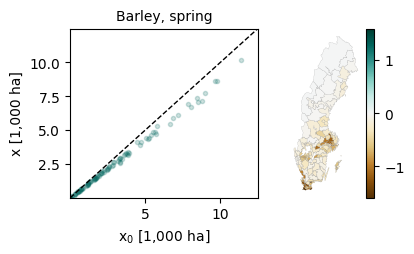

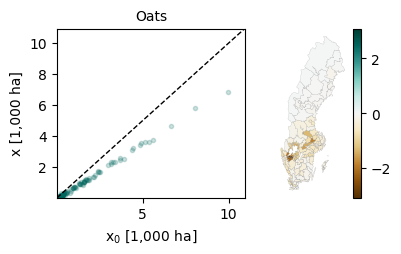

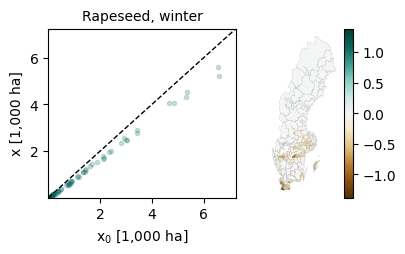

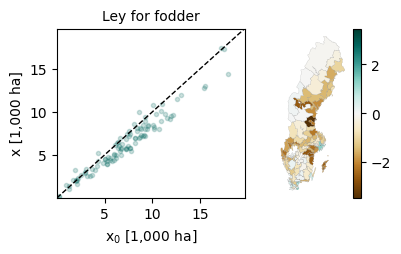

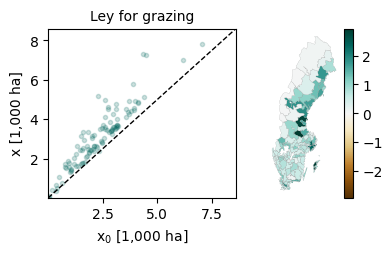

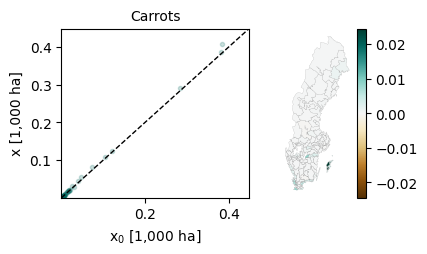

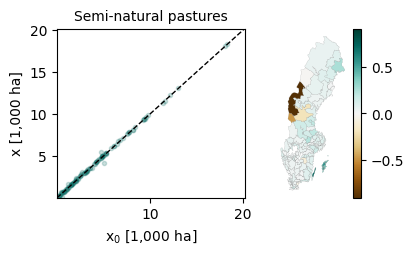

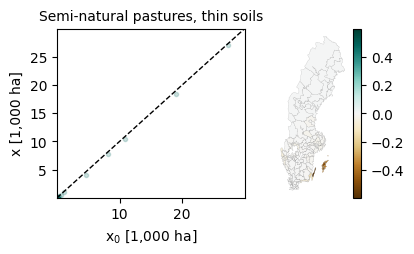

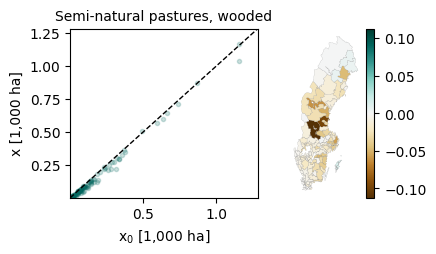

In [187]:
# Some main crops
crps = ['Wheat, winter','Barley, spring','Oats','Rapeseed, winter','Ley for fodder','Ley for grazing','Carrots','Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']

for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    lim_min = plot_data[['x0','x']].replace({0:np.nan}).min().min() * 0.1
    lim_max = plot_data[['x0','x']].max().max() * 1.1
    plot_data.plot(x='x0', y='x', ax=ax,
                   # loglog=True,
                   xlim = (lim_min,lim_max), ylim=(lim_min,lim_max),
                   linestyle='', marker='.', color='#01665e', alpha=0.2, legend=False)
    ax.axline((0,0),(1,1), color='black', linestyle='--', linewidth=1)
    ax.set_title(crp, size=10)
    ax.set_xlabel('x$_{0}$ [1,000 ha]')
    ax.set_ylabel('x [1,000 ha]')

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.show()

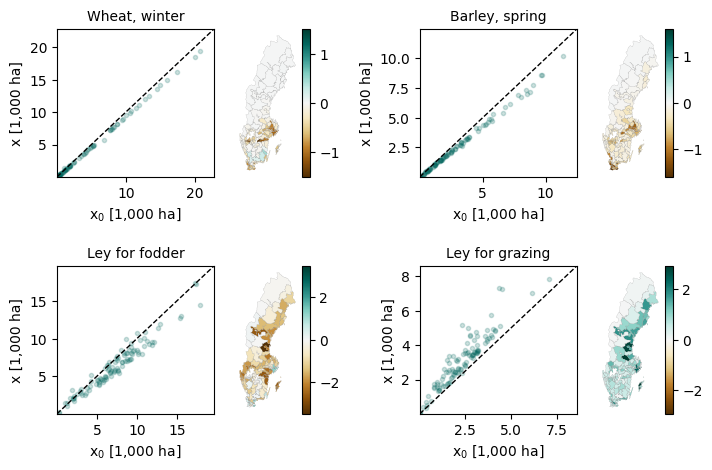

In [223]:
# Some main crops
crps = ['Wheat, winter','Barley, spring','Ley for fodder','Ley for grazing',]

fig, axs = plt.subplots(2, 5, figsize=(8, 5), 
                        gridspec_kw={'width_ratios': [2, 1, 0.8, 2, 1], 'hspace':0.6})
axs_ = axs.flatten()

axs = [axs_[i] for i in range(10) if i % 5 != 2]  # Skip middle col in each row

for i,crp in enumerate(crps):
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])

    ax=axs[i*2]
    lim_min = plot_data[['x0','x']].replace({0:np.nan}).min().min() * 0.1
    lim_max = plot_data[['x0','x']].max().max() * 1.1
    plot_data.plot(x='x0', y='x', ax=ax,
                   # loglog=True,
                   xlim = (lim_min,lim_max), ylim=(lim_min,lim_max),
                   linestyle='', marker='.', color='#01665e', alpha=0.2, legend=False)
    ax.axline((0,0),(1,1), color='black', linestyle='--', linewidth=1)
    ax.set_title(crp, size=10)
    ax.set_xlabel('x$_{0}$ [1,000 ha]')
    ax.set_ylabel('x [1,000 ha]')

    ax=axs[i*2+1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

for ax in axs_:
    if ax not in axs:
        ax.axis('off')

plt.savefig('figs/Fig3.png', dpi=300)
plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

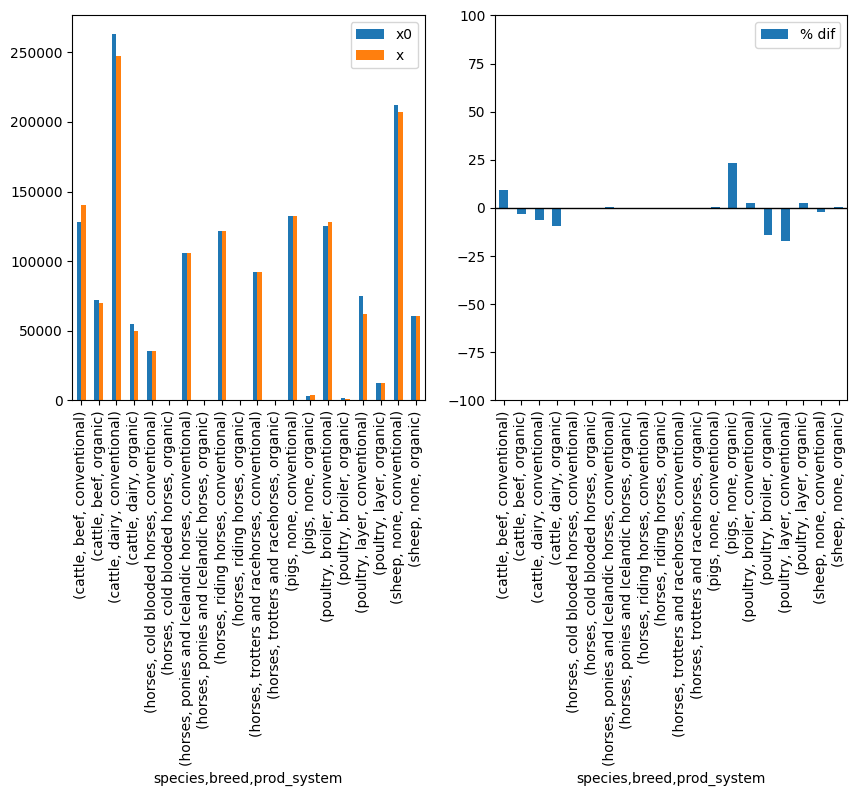

In [51]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['region','species','breed','prod_system','animal'])
        .droplevel('year')
        .rename(lambda x: x.replace('base year','x'))
        .T
        .loc[idx[:,:,:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['region','species','breed','prod_system'])
        .sum()
        ,
        session.get_attr('R','x0_animals',['region','species','breed','prod_system']).loc[(scn,year)]
        .rename('x0')
    ], axis=1)
)

# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(10,5))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

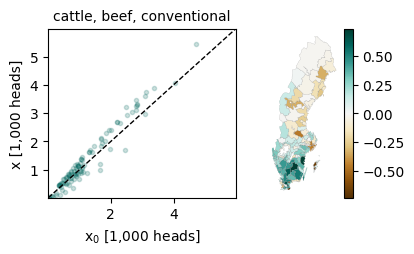

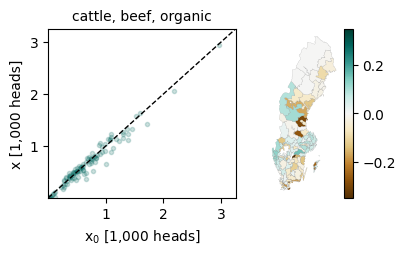

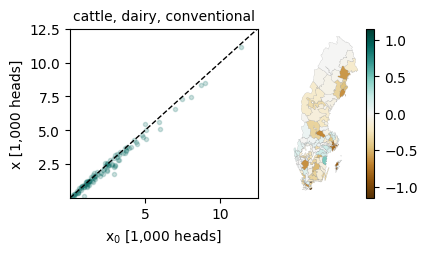

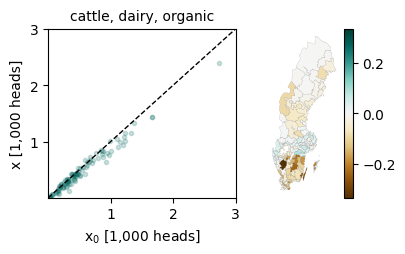

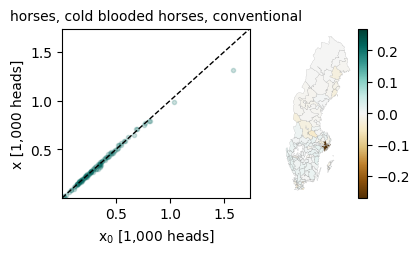

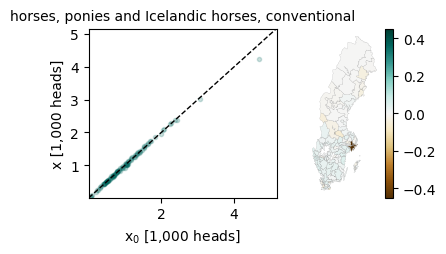

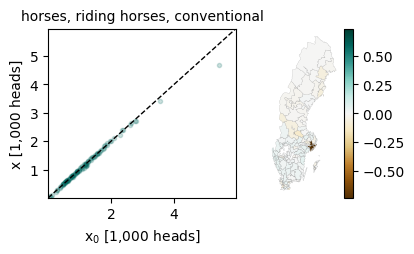

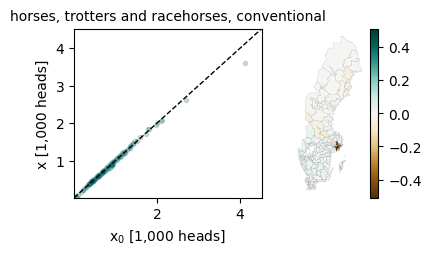

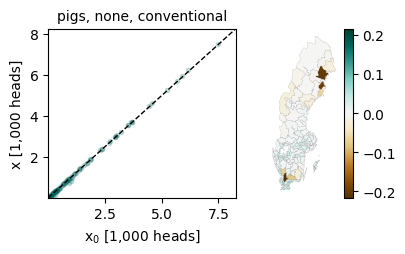

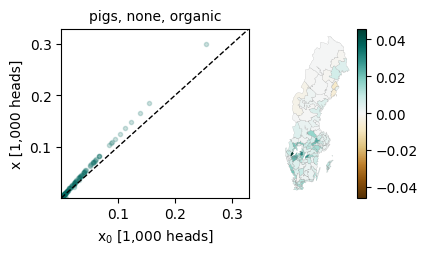

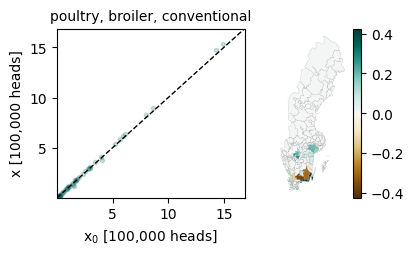

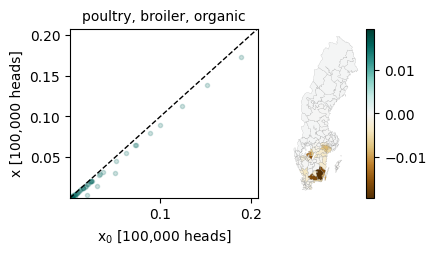

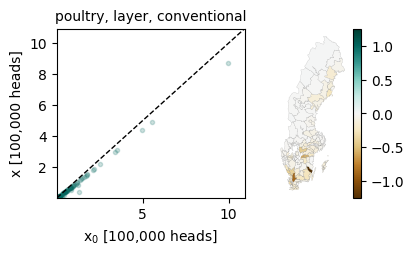

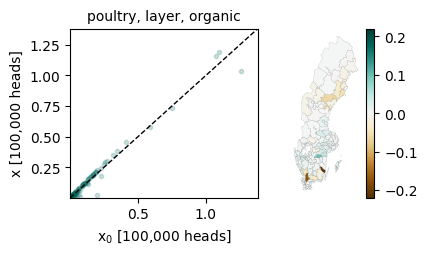

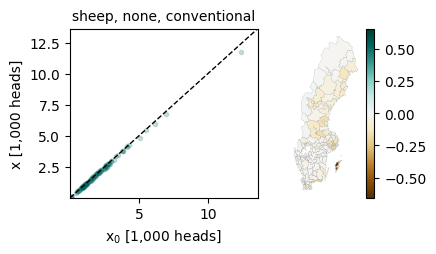

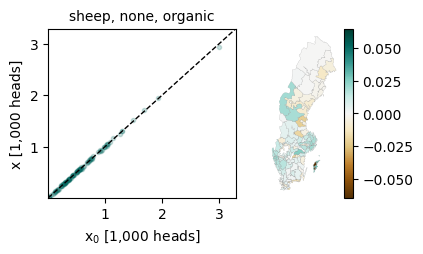

In [52]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()/1000
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])

    fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    lim_min = plot_data[['x0','x']].replace({0:np.nan}).min().min() * 0.1
    lim_max = plot_data[['x0','x']].max().max() * 1.1
    plot_data.plot(x='x0', y='x', ax=ax,
                   # loglog=True,
                   xlim = (lim_min,lim_max), ylim=(lim_min,lim_max),
                   linestyle='', marker='.', color='#01665e', alpha=0.2, legend=False)
    ax.axline((0,0),(1,1), color='black', linestyle='--', linewidth=1)
    ax.set_title(', '.join(idx), size=10)
    ax.set_xlabel(f'x$_{0}$ [1{"00" if "poultry" in idx else ""},000 heads]')
    ax.set_ylabel(f'x [1{"00" if "poultry" in idx else ""},000 heads]')

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.show()

In [224]:
len(axs_)

10

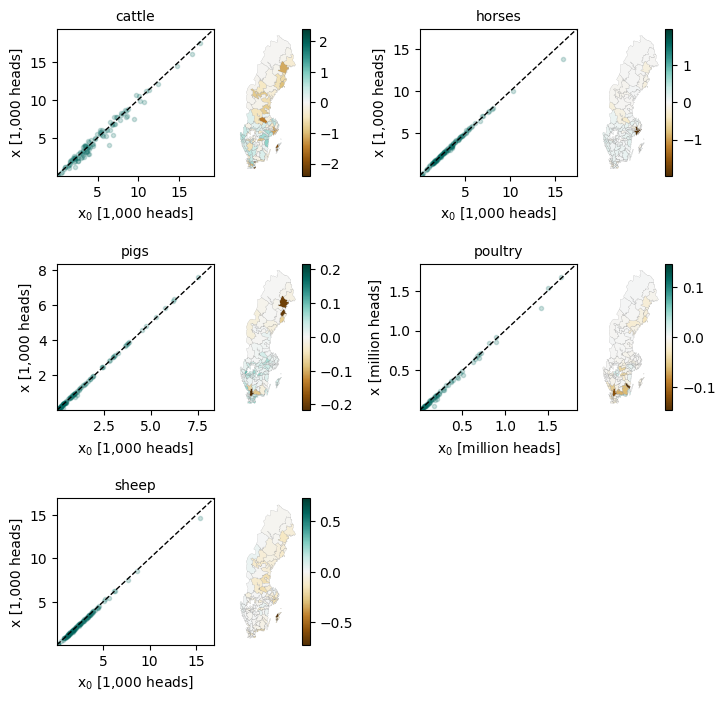

In [232]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        session.get_attr('A','heads',['species','region','animal']).droplevel('year').loc[scns].rename(lambda x: x.replace('base year', 'x')).T
        .loc[idx[:,:,[
                'cows',
                'sows','gilts',
                'broodmares','low-performing horses','medium-performing horses','young horses',
                'broilers',
                'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
                'ewes','rams'
            ]],:]
        .groupby(['species','region']).sum(),
        session.get_attr('R','x0_animals',['species','region']).loc[(scn,year)].rename('x0')
    ], axis=1)
)/1000

fig, axs = plt.subplots(3, 5, figsize=(8, 8), 
                        gridspec_kw={'width_ratios': [2, 1, 0.8, 2, 1], 'hspace':0.6})
axs_ = axs.flatten()
axs = [axs_[i] for i in range(len(axs_)) if i % 5 != 2]  # Skip middle col in each row

for i,sp in enumerate(plot_data_.index.unique('species')):
    plot_data = plot_data_.loc[sp].copy() * (1/1000 if sp == 'poultry' else 1)
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])

    # fig, axs = plt.subplots(1,2, figsize=(4,2.2), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[i*2]
    lim_min = plot_data[['x0','x']].replace({0:np.nan}).min().min() * 0.1
    lim_max = plot_data[['x0','x']].max().max() * 1.1
    plot_data.plot(x='x0', y='x', ax=ax,
                   # loglog=True,
                   xlim = (lim_min,lim_max), ylim=(lim_min,lim_max),
                   linestyle='', marker='.', color='#01665e', alpha=0.2, legend=False)
    ax.axline((0,0),(1,1), color='black', linestyle='--', linewidth=1)
    ax.set_title(sp, size=10)
    ax.set_xlabel(f'x$_{0}$ [{"million" if sp=="poultry" else "1,000"} heads]')
    ax.set_ylabel(f'x [{"million" if sp=="poultry" else "1,000"} heads]')

    ax=axs[i*2+1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

for ax in axs_:
    if ax not in axs or ax in axs_[-2:]:
        ax.axis('off')

plt.savefig('figs/Fig4.png', dpi=300)
plt.show()

In [230]:
axs_[-2:]

array([<Axes: >, <Axes: >], dtype=object)

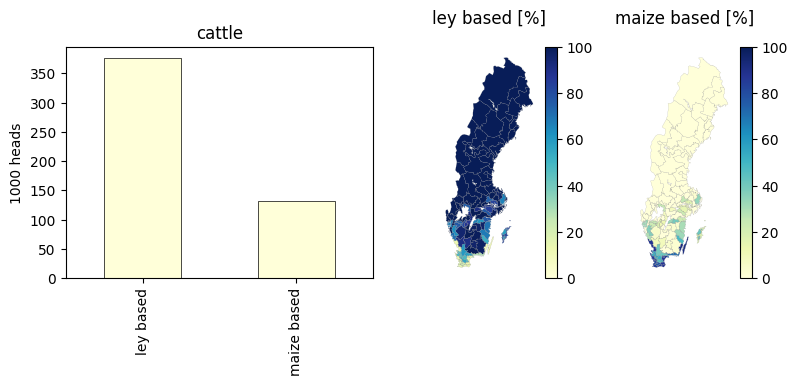

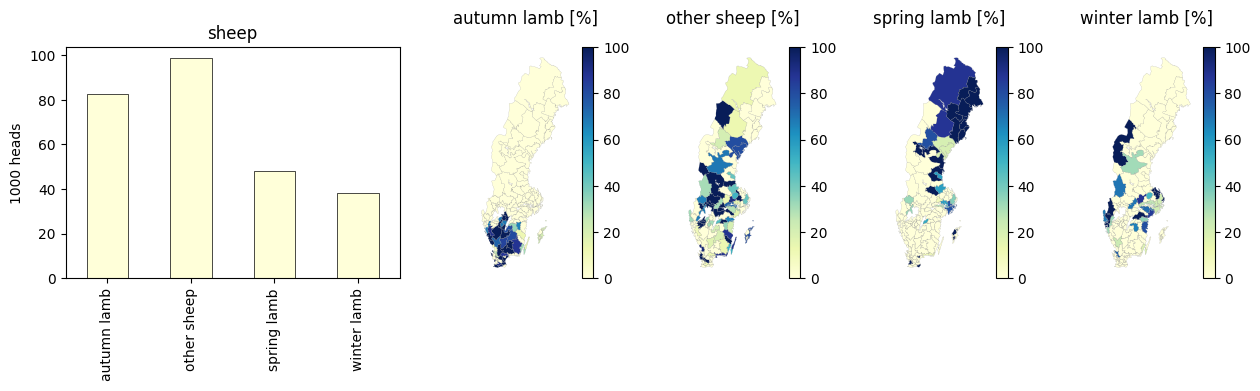

In [54]:
idx = pd.IndexSlice
plot_data = (
    session.get_attr('A','heads',['species','sub_system','region','animal']).loc[(scn,year)]
    .loc[idx[:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters',
            'ewes','rams'
        ]]]
    .groupby(['species','sub_system','region'])
    .sum()
)/1000


for sp in plot_data.index.get_level_values('species').unique():
    plot_data_ = plot_data.xs(sp)
    sss = plot_data_.index.get_level_values('sub_system').unique()
    n_ss = len(sss)
    if n_ss>1:
        fig, axs = plt.subplots(1, 1+n_ss, figsize=(3+3*n_ss,3), gridspec_kw={'width_ratios': [2] + [1]*n_ss})
        ax=axs[0]
        plot_data_.groupby('sub_system').sum().plot(**pd_bar_style, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('1000 heads')
        ax.set_title(sp)
        
        map_data = plot_data_.groupby('region').transform(lambda x: x/x.sum() * 100)
        for ax,ss in zip(axs[1::],sss):
            plot.map_from_series(
                map_data.xs(ss),
                ax=ax,
                vmin=0,
                vmax=100,
                **map_style
            )
            ax.set_title(ss + ' [%]')
            ax.axis('off')
            
        plt.show()

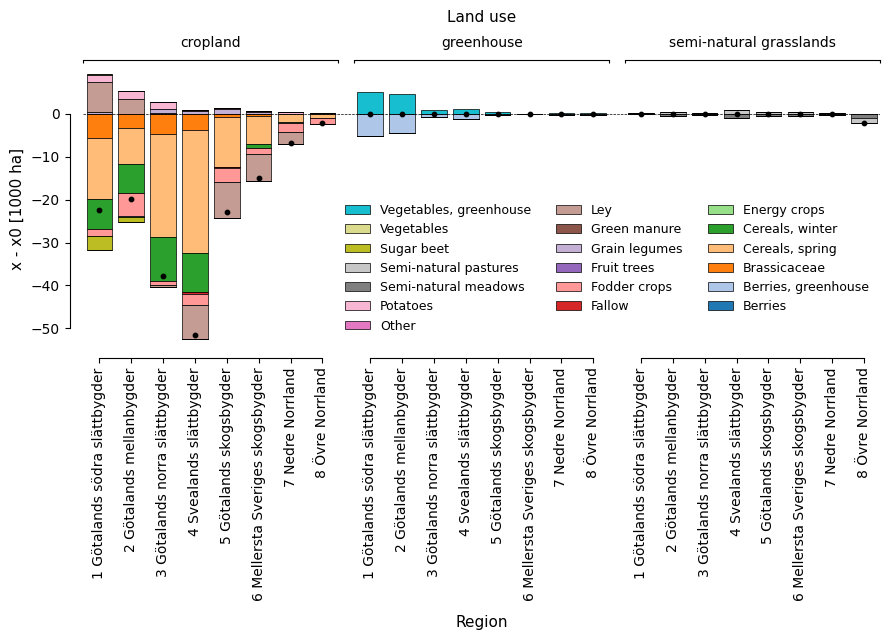

In [55]:
fig = plt.figure(figsize=(9,6.5))
data = (
    (session.get_attr('cr','area',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0] -
    session.get_attr('r','x0_crops',{'crop':['land_use','crop_group'],'region':'po8'}).iloc[0]) / 1000
).unstack('crop_group')
ax = plot.bar(data, stacked=True, group_levels='land_use', sort_xlabels=False, sort_groups=False, cmap='tab20', grouptitle='Land use', xlabel='Region', ylabel='x - x0 [1000 ha]')

plt.tight_layout()
plt.show()

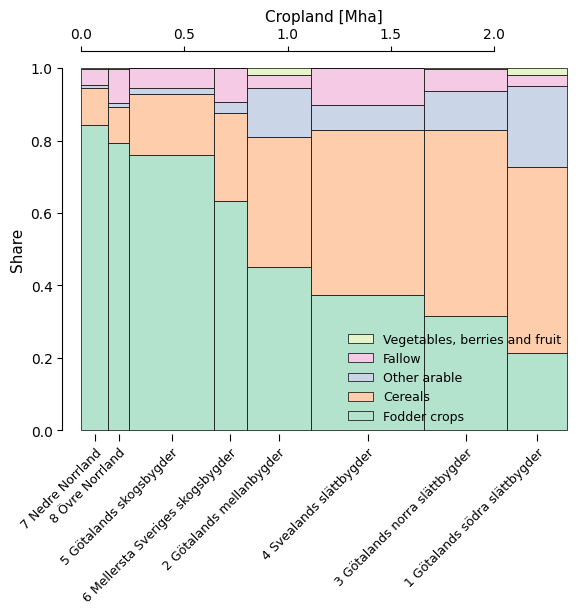

In [56]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'],'region':'po8'}).iloc[0].loc['cropland'].unstack('crop_group2') / 1000000
ax = plot.marimekko(data, xlabel='Cropland [Mha]', ylabel='Share', cmap='Pastel2')
plt.show()

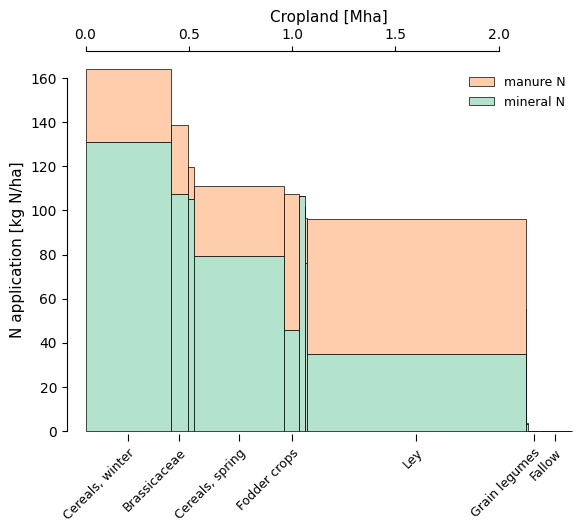

In [57]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral N'),
    session.get_attr('c','fertiliser.manure_N',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure N'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='N application [kg N/ha]', cmap='Pastel2')
plt.show()

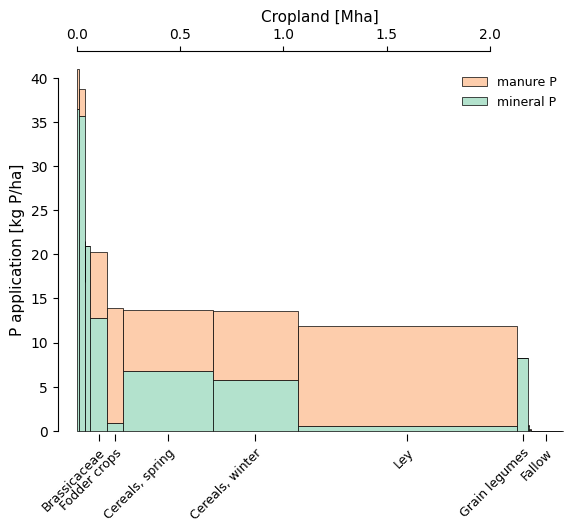

In [58]:
data = pd.concat([
    session.get_attr('c','fertiliser.mineral_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('mineral P'),
    session.get_attr('c','fertiliser.manure_P',{'crop':['land_use','crop_group']}).iloc[0]
    .div(session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0], axis=0).rename('manure P'),
    session.get_attr('c','area',{'crop':['land_use','crop_group']}).iloc[0].rename('x') / 1000000
], axis=1).fillna(0).loc['cropland']
plot.marimekko(data, x_column='x', xlabel='Cropland [Mha]', ylabel='P application [kg P/ha]', cmap='Pastel2', xcategorylabels_threshold=0.02, xcategorylabels_fontsize=9)
plt.show()

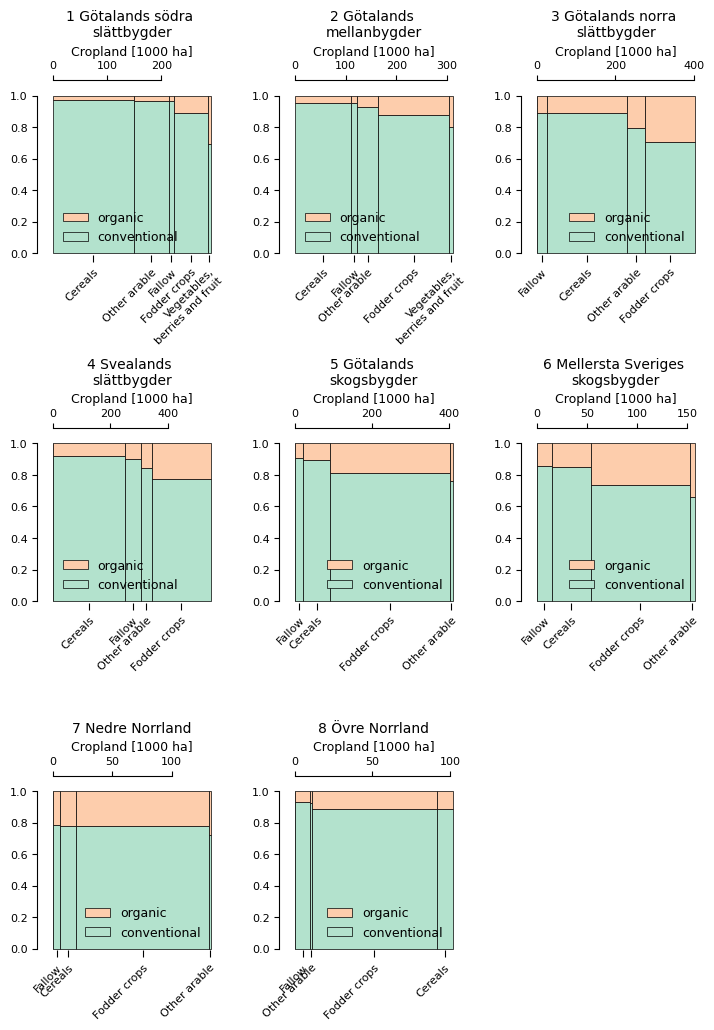

In [59]:
data = session.get_attr('c','area',{'crop':['land_use','crop_group2'], 'region':'po8', 'prod_system':None}).iloc[0].loc['cropland'].unstack()/1000
fig, axs = plot.subplots(data, index='po8', plot_fn=plot.marimekko, size=(2.5,3.5), cmap='Pastel2', title_fontsize=10, xcategorylabels_threshold=0.01,
                         xcategorylabels_wrap=18, xcategorylabels_fontsize=8, xlabel='Cropland [1000 ha]', xlabel_fontsize=9, ticklabels_fontsize=8)
plt.tight_layout(pad=2)
plt.show()

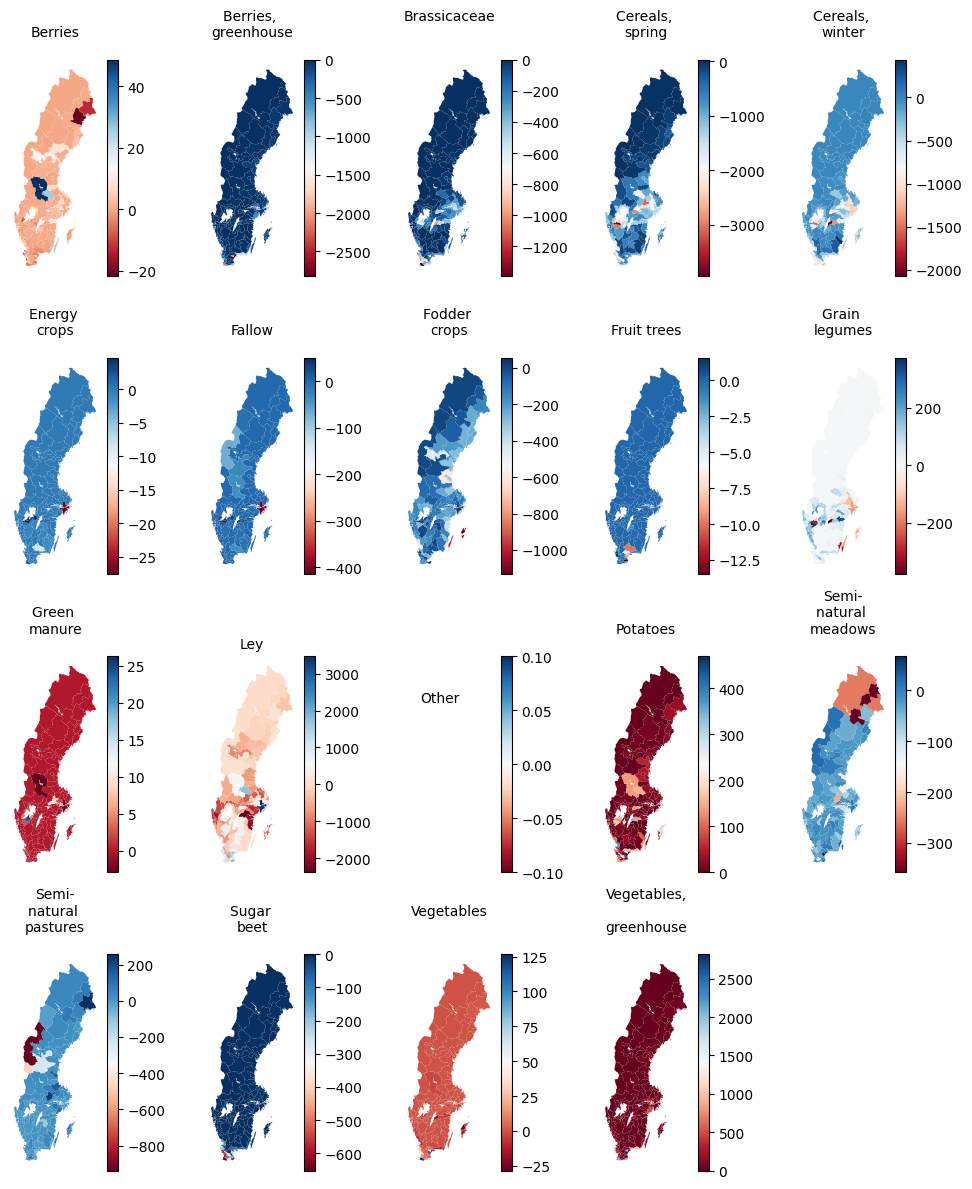

In [60]:
data = (session.get_attr('c','area',{'crop':'crop_group','region':None}) - session.get_attr('r','x0_crops',{'crop':'crop_group','region':None})).iloc[0]

fig, axs = plot.subplots(data, index='crop_group', title_fontsize=10, size=(2,3), plot_fn=plot.map_from_series, cmap='RdBu')
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

## Run baseline calculations

In [11]:
%%time
cm.ParameterRetriever.update_relation_tables()
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    regions = regions
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate cover crops management
cover_crops_mgmt = cm.CoverCropsMgmt(
    crops = crops,
    par = cm.ParameterRetriever('CoverCropsMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    cover_crops_mgmt = cover_crops_mgmt,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

CPU times: total: 7.06 s
Wall time: 8.39 s


In [23]:
session.store?

Signature: session.store(scn, year, *args)
Docstring:
Write output data to database file.

Parameters
----------
scn : str
    Scenario name
year : str
    Year
*args : CIBUSmod main moduels / iterable of AnimalHerd objects
    Pass in the modules to store output data for
    
File:      c:\users\jnka0003\git repos\cibusmod\cibusmod\utils\session_db.py
Type:      method

In [17]:
geodist.make?

Signature:
geodist.make(
    use_cons: list | str,
    scale_power: float = 0.4,
    scale_cutoff_percentile: float = 99,
    verbose: bool = False,
    **kwargs,
)
Docstring:
Creates constraints and defines optimisation problem

Parameters
----------
use_cons : (list of) str
    List of numbers corresponding to the constraints to be used. For descriptions
    of each constraint see ?GeoDistributor.make_C<nr>
scale_power : float, default 0.4
    Power used to calculate scaling factors for the optimisation.
    scale_power=0 -> minimise absolute difference in crop areas/animal numbers
    scale_poqer=1 -> minimise relative difference in crop areas/animal numbers
    See ?GeoDistributor.calculate_scaling_factors for details
scale_cutoff_percentile : float (0-100), default 99
    Percentile cutoff for scaling factors. Should be <100 to avoid effectively
    removing crops/animals where x0 is close to zero from the solution.
    See ?GeoDistributor.calculate_scaling_factors for details
ver

In [5]:
%%time
# Set to true to print progress messages
msg = True
scale_powers = {
    'base year (sp=0.2)' : 0.2,
    'base year (sp=0.8)' : 0.8,
}

# Loop through scenarios and years
for scn, year in session.iterate('all'):
    print(scn,year)
    # Reload parameter data
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Induce beef exports in DemandAndConversions if beef production from dairy
    # systems under given demand for milk products exceeds total beef demand.
    # This is to avoid not finding any solution when running the GeoDistributor.
    cm.helpers.induce_beef_exports(
        demand = demand,
        herds = herds
    )
    

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=scale_powers.get(scn, 0.4), verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg, apply_solution=False)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with {type(e).__name__}: {e}')
        continue

    if 'x0 crop areas' in scn:
        # Set crop areas to x0 areas (for validation)
        geodist.x['crp'] = geodist.x0['crp']

    # Apply solution
    geodist.apply_solution()
        
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate cover crop areas
    cover_crops_mgmt.calculate(verbose=msg)

    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )

base year 2020
[09:50:07][Regions] Getting initial crop areas and animal numbers (x0) ... 0.1s
[09:50:07][Regions] Getting climate and soil attributes ... 0.0s
[09:50:07][Regions] Calculating maximum land use ... 0.0s
[09:50:07][Regions] Done! Elapsed time: 0 sec
[09:50:07][DemandAndConversions] Calculating food demand ... 0.1s
[09:50:07][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[09:50:07][DemandAndConversions] Calculating waste ... 0.0s
[09:50:07][DemandAndConversions] Calculating nutrient supply from diet ... 0.0s
[09:50:07][DemandAndConversions] Calculating product demand and generated by-products... 0.2s
[09:50:08][DemandAndConversions] Done! Elapsed time: 0 sec
[09:50:08][CropProduction] Calculating harvest ... 0.1s
[09:50:08][CropProduction] Calculating production ... 0.5s
[09:50:08][CropProduction] Calculating crop residues ... 0.1s
[09:50:08][CropProduction] Calculating seed demand ... 0.2s
[09:50:09][CropProduction] Done! Elapsed time: 1 sec
[09:50:

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt.py:103: UserWarning: FeedMgmt: Specified domestic shares for 'by_prod' will have no effect! 
For by-products, imports are handled in the ByProductMgmt module and for crop residues, imports are not allowed.
  warnings.warn(


0.7s
[09:50:29][FeedMgmt] Calculating demand for crop residues ... 0.2s
[09:50:29][FeedMgmt] Done! Elapsed time: 9 sec
[09:50:29][GeoDistributor.make] Getting x0 and making indexes ... 0.0s
[09:50:29][GeoDistributor.make] Creating demand vector ... 0.2s
[09:50:29][GeoDistributor.make] Calculating scaling factors ... 0.0s
[09:50:29][GeoDistributor.make] Making objective O1 ... 0.1s
[09:50:29][GeoDistributor.make] Making constraint C1 ... 6.4s
[09:50:36][GeoDistributor.make] Making constraint C2 ... 0.5s
[09:50:36][GeoDistributor.make] Making constraint C3 ... 0.3s
[09:50:37][GeoDistributor.make] Making constraint C4 ... 0.2s
[09:50:37][GeoDistributor.make] Making constraint C5 ... 0.1s
[09:50:37][GeoDistributor.make] Making constraint C6 ... 0.5s
[09:50:37][GeoDistributor.make] Making constraint C7 ... 0.5s
[09:50:38][GeoDistributor.make] Done! Elapsed time: 9 sec
[09:50:38][GeoDistributor.solve] Defining problem ... 0.0s
[09:50:38][GeoDistributor.solve] Finding solution with 'GUROBI' .

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_VS.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_N.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_P.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_K.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\C

Outputs stored!
base year (x0 crop areas) 2020
[09:52:16][Regions] Getting initial crop areas and animal numbers (x0) ... 0.1s
[09:52:16][Regions] Getting climate and soil attributes ... 0.0s
[09:52:16][Regions] Calculating maximum land use ... 0.0s
[09:52:16][Regions] Done! Elapsed time: 0 sec
[09:52:16][DemandAndConversions] Calculating food demand ... 0.1s
[09:52:16][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[09:52:16][DemandAndConversions] Calculating waste ... 0.0s
[09:52:16][DemandAndConversions] Calculating nutrient supply from diet ... 0.0s
[09:52:16][DemandAndConversions] Calculating product demand and generated by-products... 0.5s
[09:52:17][DemandAndConversions] Done! Elapsed time: 1 sec
[09:52:17][CropProduction] Calculating harvest ... 0.0s
[09:52:17][CropProduction] Calculating production ... 0.5s
[09:52:17][CropProduction] Calculating crop residues ... 0.1s
[09:52:17][CropProduction] Calculating seed demand ... 0.2s
[09:52:18][CropProduction] D

...

Outputs stored!
base year (sp=0.8) 2020
[09:56:04][Regions] Getting initial crop areas and animal numbers (x0) ... 0.1s
[09:56:04][Regions] Getting climate and soil attributes ... 0.0s
[09:56:04][Regions] Calculating maximum land use ... 0.0s
[09:56:04][Regions] Done! Elapsed time: 0 sec
[09:56:04][DemandAndConversions] Calculating food demand ... 0.1s
[09:56:04][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[09:56:04][DemandAndConversions] Calculating waste ... 0.0s
[09:56:04][DemandAndConversions] Calculating nutrient supply from diet ... 0.0s
[09:56:04][DemandAndConversions] Calculating product demand and generated by-products... 0.2s
[09:56:04][DemandAndConversions] Done! Elapsed time: 0 sec
[09:56:04][CropProduction] Calculating harvest ... 0.0s
[09:56:04][CropProduction] Calculating production ... 0.4s
[09:56:05][CropProduction] Calculating crop residues ... 0.0s
[09:56:05][CropProduction] Calculating seed demand ... 0.1s
[09:56:05][CropProduction] Done! El

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\mgmt_modules\feed_mgmt\feed_mgmt.py:103: UserWarning: FeedMgmt: Specified domestic shares for 'by_prod' will have no effect! 
For by-products, imports are handled in the ByProductMgmt module and for crop residues, imports are not allowed.
  warnings.warn(


0.5s
[09:56:21][FeedMgmt] Calculating demand for crop residues ... 0.1s
[09:56:22][FeedMgmt] Done! Elapsed time: 6 sec
[09:56:22][GeoDistributor.make] Getting x0 and making indexes ... 0.0s
[09:56:22][GeoDistributor.make] Creating demand vector ... 0.1s
[09:56:22][GeoDistributor.make] Calculating scaling factors ... 0.0s
[09:56:22][GeoDistributor.make] Making objective O1 ... 0.3s
[09:56:22][GeoDistributor.make] Making constraint C1 ... 4.5s
[09:56:27][GeoDistributor.make] Making constraint C2 ... 0.4s
[09:56:27][GeoDistributor.make] Making constraint C3 ... 0.2s
[09:56:27][GeoDistributor.make] Making constraint C4 ... 0.2s
[09:56:27][GeoDistributor.make] Making constraint C5 ... 0.0s
[09:56:27][GeoDistributor.make] Making constraint C6 ... 0.4s
[09:56:28][GeoDistributor.make] Making constraint C7 ... 0.4s
[09:56:28][GeoDistributor.make] Done! Elapsed time: 7 sec
[09:56:28][GeoDistributor.solve] Defining problem ... 0.0s
[09:56:28][GeoDistributor.solve] Finding solution with 'GUROBI' .

C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_VS.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_N.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_P.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1543: UserWarning: NaNs in WasteAndCircularity.losses_K.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users\jnka0003\Git repos\C

Outputs stored!
CPU times: total: 6min 22s
Wall time: 7min 36s
